# Fit a 2-D Exponential to a 2-D histogram of star counts from Match Filter
## Charlotte Christensen, June 18, 2026

In [1]:
import numpy as np
from astropy.io import fits
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from pathlib import Path as path
import os
import re

In [2]:
box = 'r'
num = '442'
galaxy_name = f'{box}_{num}'
numpix=8000

In [3]:
# 1. Define the 2-D exponential model function
# The first argument must accept the combined X and Y coordinate array
def exponential_2d(coords, A, h, q, x_offset, y_offset, theta, C):
    # Parameters: A is amplitude, h is scale length, q is axis ratio (ie., minor/major; related to orientation), 
    # theta is rotation angle in viewing plane, C is offset from background (should be about zero)
    # theta = 0 means major axis is along x-axis, theta = pi/2 means major axis is along y-axis
    x = coords[0] - x_offset
    y = coords[1] - y_offset
    x_prime = x * np.cos(theta) + y * np.sin(theta)
    y_prime = -x * np.sin(theta) + y * np.cos(theta)
    r = np.sqrt(x_prime**2 + y_prime**2/q**2)
    return A * np.exp(-r/h) + C

In [4]:
def twod_exp_fit(Z_fitted, d, a, save=True, inv_y=True):

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot the original noisy data as an image
    im = ax.imshow(Z_fitted, origin='lower', extent=[x_line.min(), x_line.max(), y_line.min(), y_line.max()], 
                   cmap='viridis', vmin=-2, vmax=30, aspect='auto')

    # Overlay contours of the fitted result
    levels_arr = 10.0**np.array([-4,-3,-2,-1])*(A_fit + C_fit)
    #contours = ax.contour(X, Y, Z_fitted, colors='white', linewidths=2, levels=levels_arr, alpha=0.8)
    #ax.clabel(contours, inline=True, fontsize=8, fmt='%.2f')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Value', rotation=270, labelpad=20)

    # Labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'{galaxy_name} (Image) with Fitted Model Contours (White)')

    plt.tight_layout()

    if save==True:
        fitted_path = path(f'/home/giantsid/MAP/substructure_detection/sd_outputs/twod_exp_fit/{galaxy_name}/fitted/{galaxy_name}_fitted_d={d}_a={a}_pix={numpix}.png')
        fitted_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(fitted_path)

    if inv_y==True:
        plt.gca().invert_yaxis()
    
    plt.show()

In [5]:
def twod_exp_fit_res(d, a, save=True, inv_y=True):

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot the original noisy data as an image
    im = ax.imshow(masked_residual, origin='lower', extent=[x_line.min(), x_line.max(), y_line.min(), y_line.max()], 
                   cmap='viridis', vmin=-2, vmax=30, aspect='auto')

    # Overlay contours of the fitted result
    #contours = ax.contour(X, Y, Z_fitted, colors='white', linewidths=2, levels=[0.03, 0.3, 8], alpha=0.8)
    #ax.clabel(contours, inline=True, fontsize=8, fmt='%.2f')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Value', rotation=270, labelpad=20)

    # Labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'{galaxy_name} (Image) with Fitted Model Contours (White) Around the Center')

    plt.tight_layout()

    if save==True:
        reduced_path = path(f'/home/giantsid/MAP/substructure_detection/sd_outputs/twod_exp_fit/{galaxy_name}/reduced/{galaxy_name}_reduced_d={d}_a={a}_pix={numpix}.png')
        reduced_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(reduced_path)
        hdu = fits.PrimaryHDU(masked_residual)
        exp_save_path = path(f'/home/giantsid/MAP/substructure_detection/sd_outputs/twod_exp_fit/{galaxy_name}/fits_files/exp_{galaxy_name}_d={d}_a={a}_pix={numpix}.fits')
        exp_save_path.parent.mkdir(parents=True, exist_ok=True)
        hdu.header['SRC_ID'] = str(exp_save_path)
        hdu.writeto(exp_save_path, overwrite=True)

    if inv_y==True:
        plt.gca().invert_yaxis()

    plt.show()

In [6]:
mf_catalogs_path = path(f'/home/giantsid/MAP/matched_filter/mf_data/mf_catalogs/{galaxy_name}')
centers_path = path(f'/home/giantsid/MAP/substructure_detection/sd_outputs/twod_exp_fit/{galaxy_name}/centers.txt')
centers_path.parent.mkdir(parents=True, exist_ok=True)
best_init_guess_path = path(f'/home/giantsid/MAP/substructure_detection/sd_outputs/twod_exp_fit/{galaxy_name}/best_init_guess.txt')
best_init_guess_path.parent.mkdir(parents=True, exist_ok=True)

In [7]:
# Provide a sensible initial guess (p0) to prevent divergence
# Form: [A, h, q, x_offset, y_offset, theta, C]
initial_guess = [6750, 2.4, 1, 3.8, 0, -2.9, -0.4]

update = True

if update == True:
    if os.path.exists(best_init_guess_path):
        os.remove(best_init_guess_path)
    with open(f'{best_init_guess_path}', 'a') as file:
                file.write('Best initial guess for ' f'{galaxy_name}' ': ' \
                           f'{initial_guess[0]}' ', ' \
                           f'{initial_guess[1]}' ', ' \
                           f'{initial_guess[2]}' ', ' \
                           f'{initial_guess[3]}' ', ' \
                           f'{initial_guess[4]}' ', ' \
                           f'{initial_guess[5]}' ', ' \
                           f'{initial_guess[6]}' '.')

File name: mf_r_442_d=0.0_a=0.0_pix=8000.fits
Fitted Parameters:
A  = 6994.5026
h = 1.7748
q = 1.6728
x_offset = 4.1023
y_offset = 1.8810
theta = -8479087.4014
C  = -0.3489


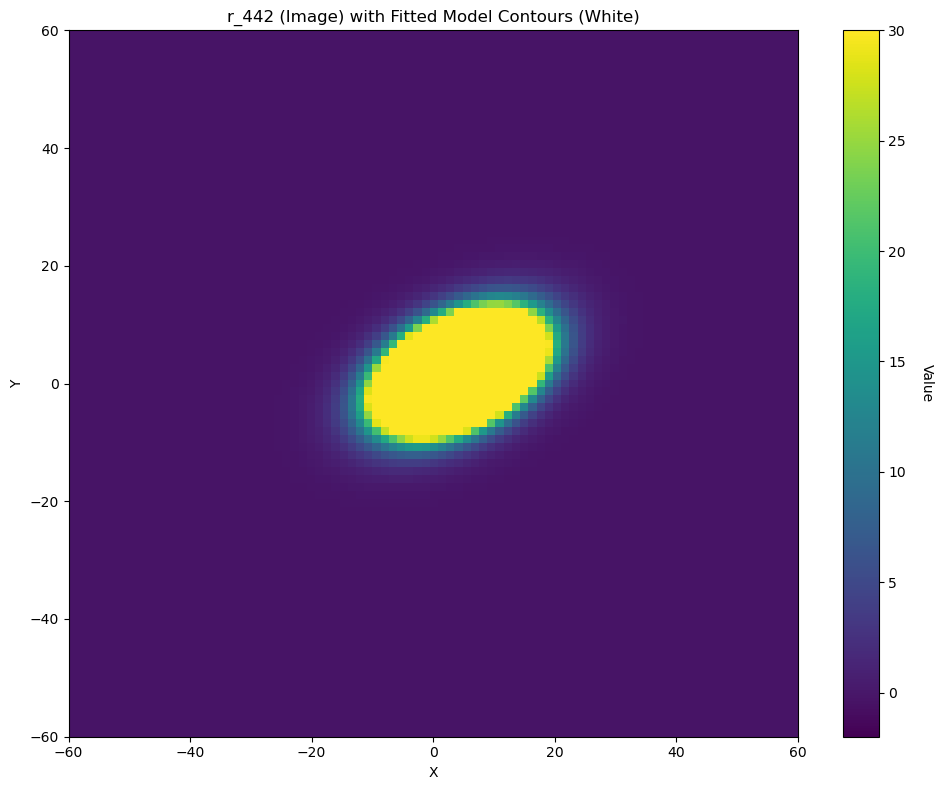

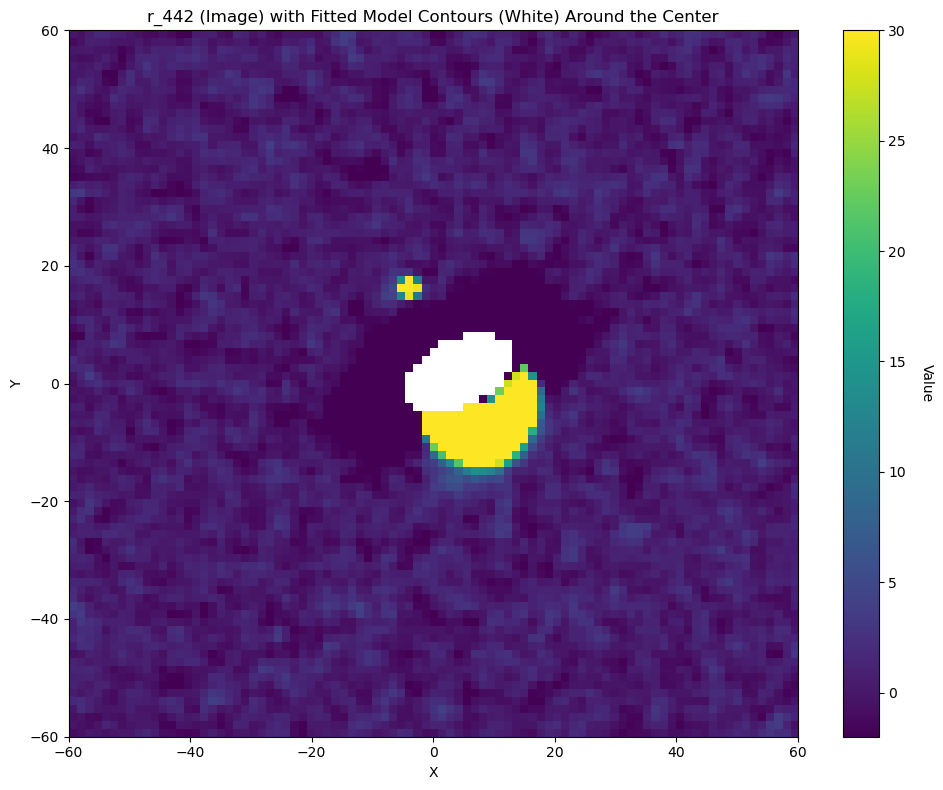

File name: mf_r_442_d=17.0_a=222.5_pix=8000.fits
Fitted Parameters:
A  = 6535.8269
h = 1.8063
q = 1.7264
x_offset = 3.5865
y_offset = -0.8051
theta = -10963052.0417
C  = -0.4347


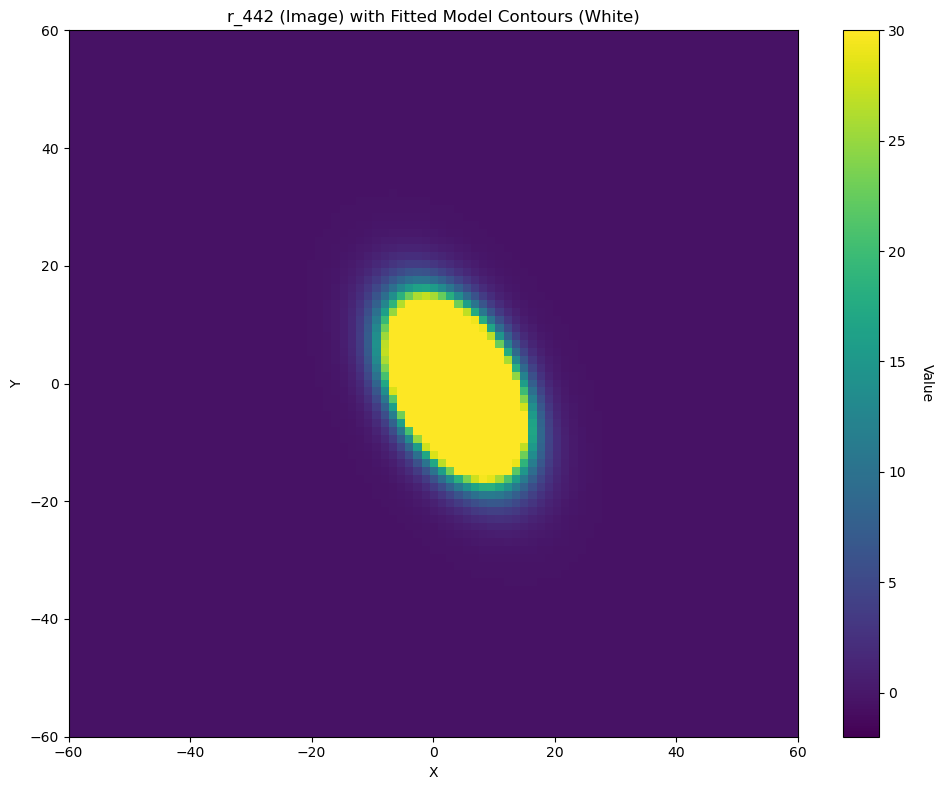

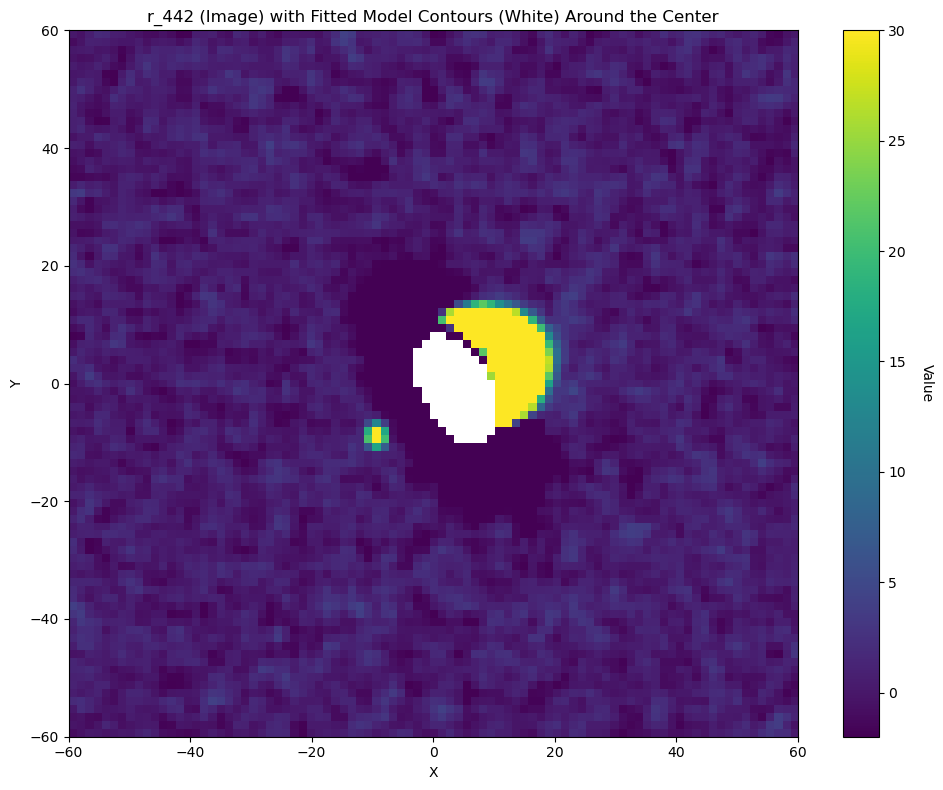

File name: mf_r_442_d=24.1_a=85.0_pix=8000.fits
Fitted Parameters:
A  = 9149.5448
h = 2.2909
q = 0.7571
x_offset = 6.1572
y_offset = 0.5773
theta = 26074567.5599
C  = -0.1961


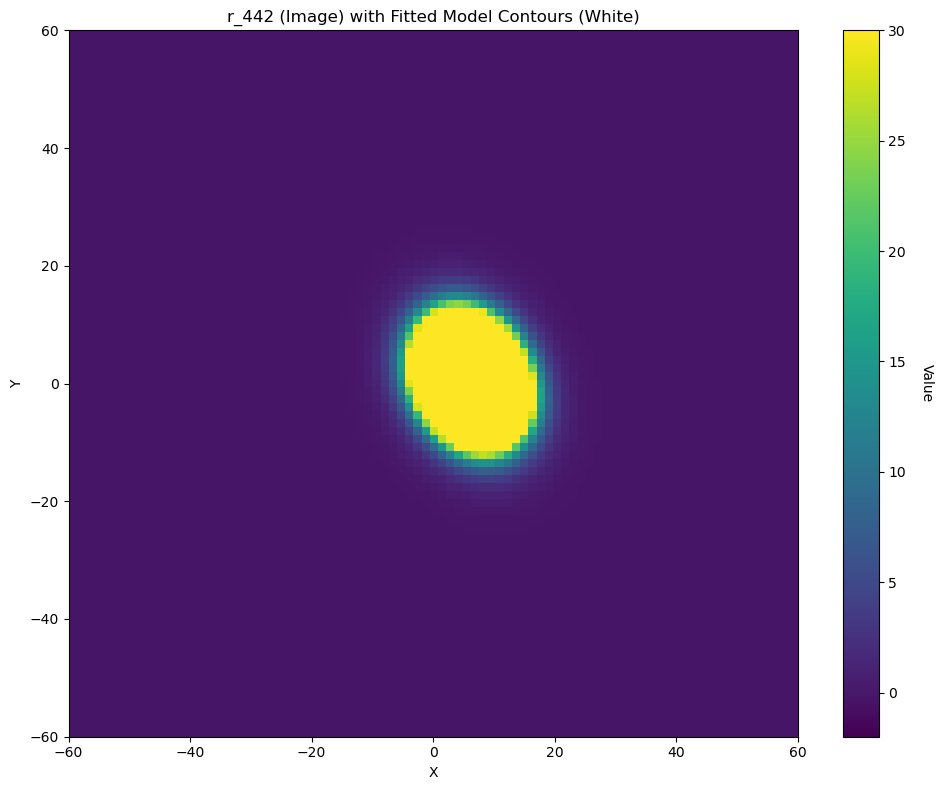

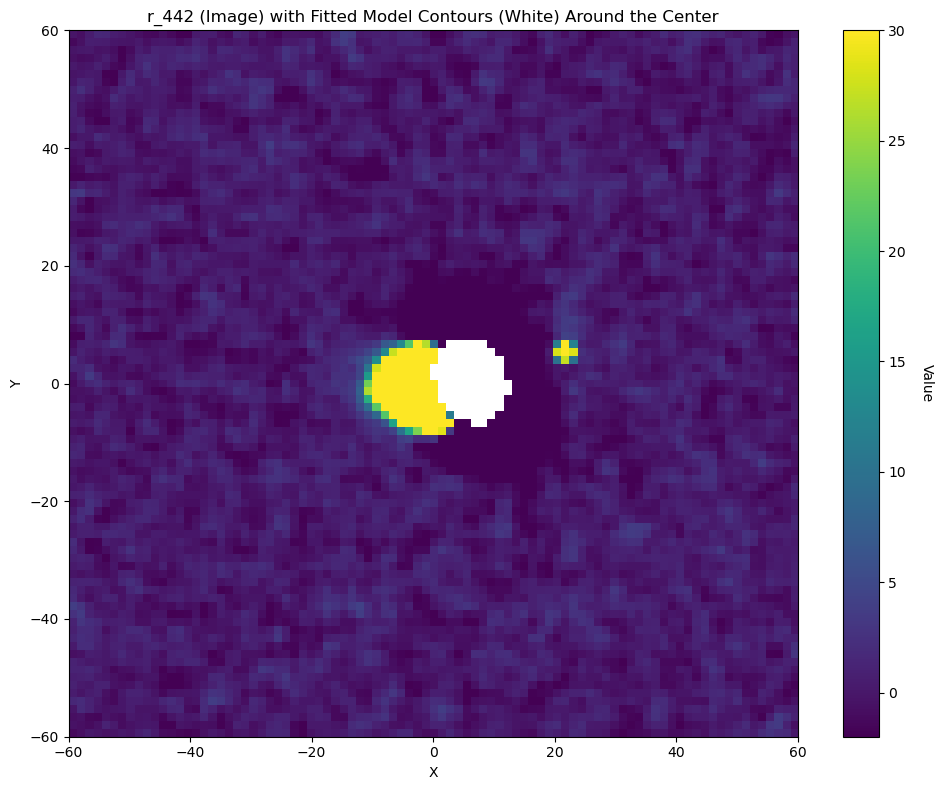

File name: mf_r_442_d=29.6_a=307.5_pix=8000.fits
Fitted Parameters:
A  = 6960.9581
h = 1.6759
q = 1.8668
x_offset = 3.3886
y_offset = 0.5540
theta = -8034501.0287
C  = -0.2762


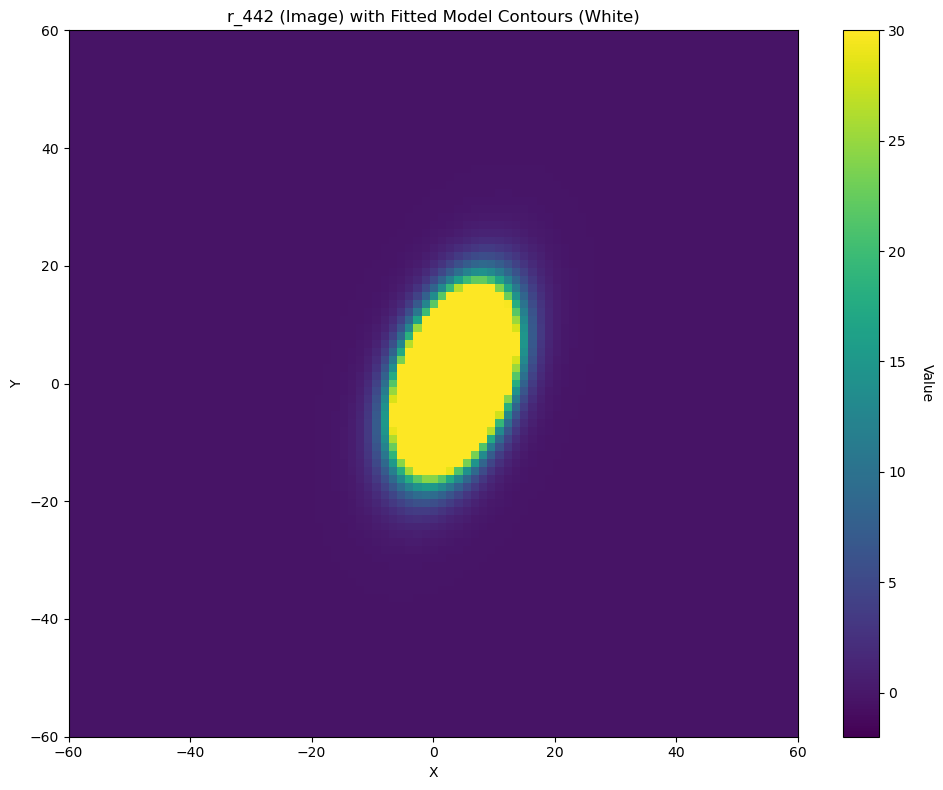

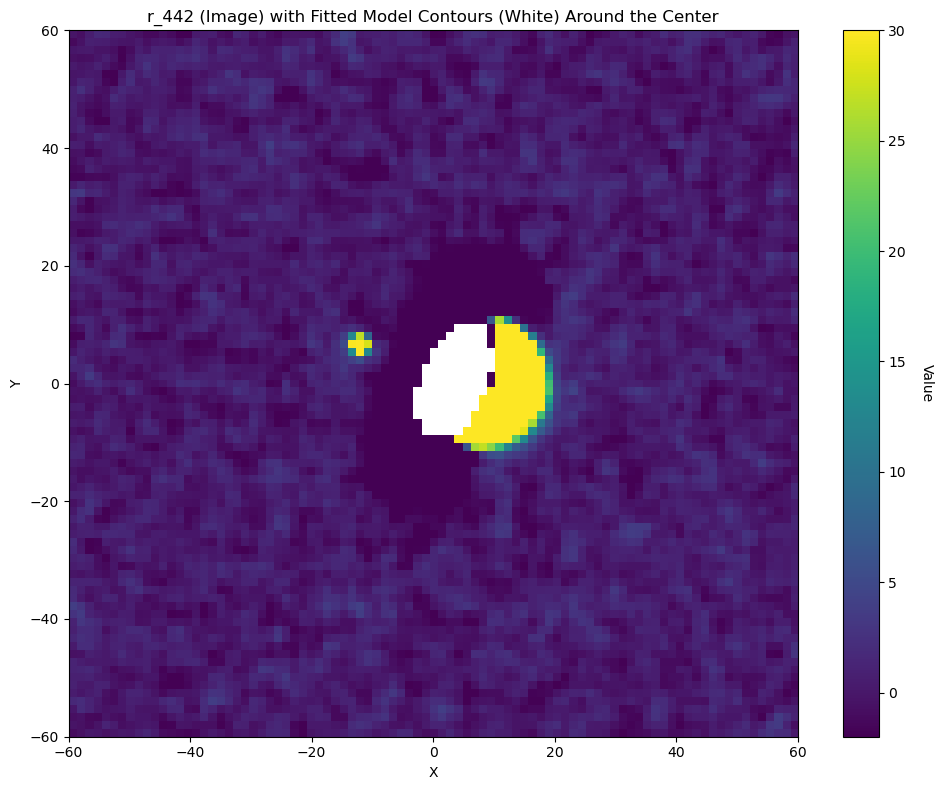

File name: mf_r_442_d=34.3_a=170.0_pix=8000.fits
Fitted Parameters:
A  = 7262.0124
h = 1.7637
q = 1.6849
x_offset = 4.4869
y_offset = -1.5388
theta = -6081434.5159
C  = -0.8744


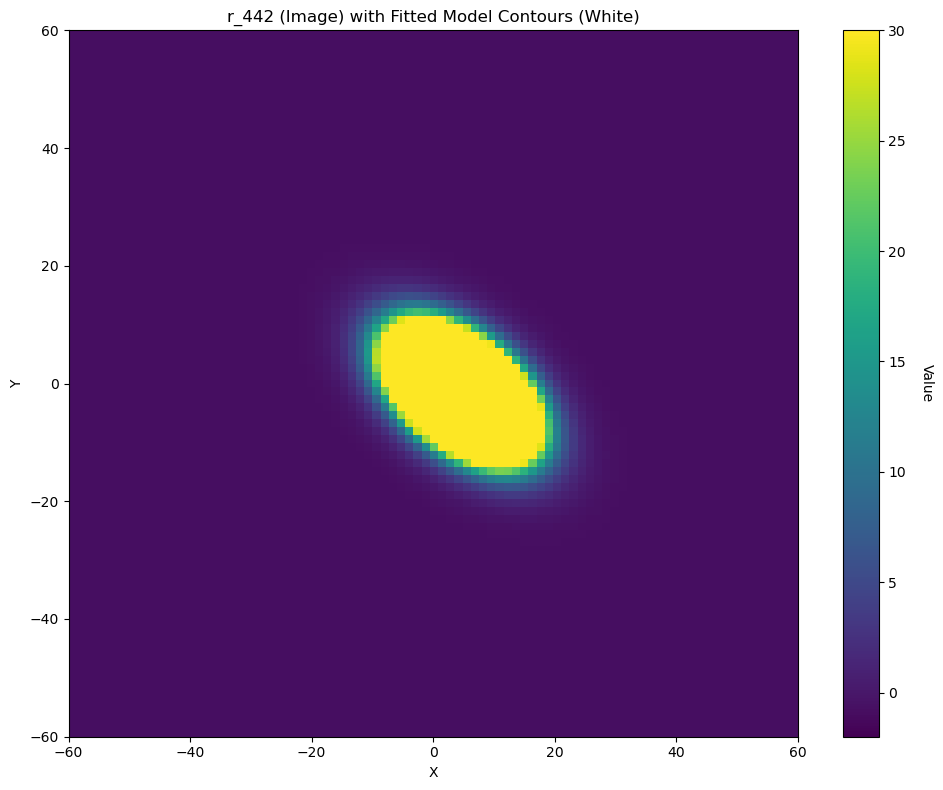

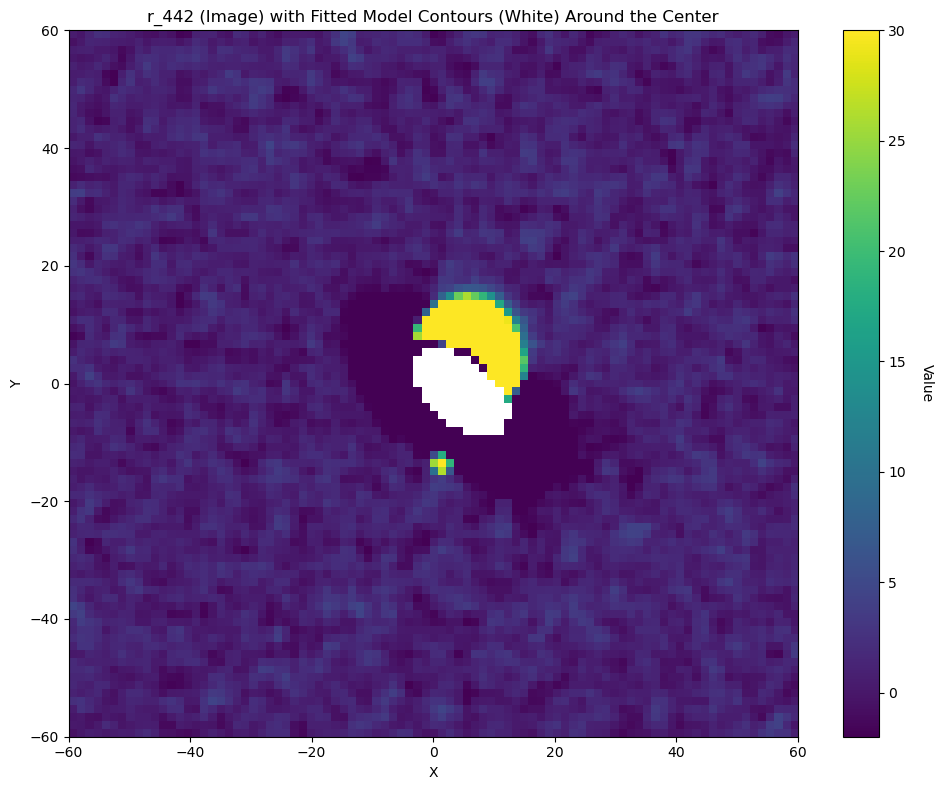

File name: mf_r_442_d=38.5_a=32.5_pix=8000.fits
Fitted Parameters:
A  = 9346.2035
h = 2.7791
q = 0.5365
x_offset = 4.5050
y_offset = 1.6427
theta = -14966879.9042
C  = -0.8840


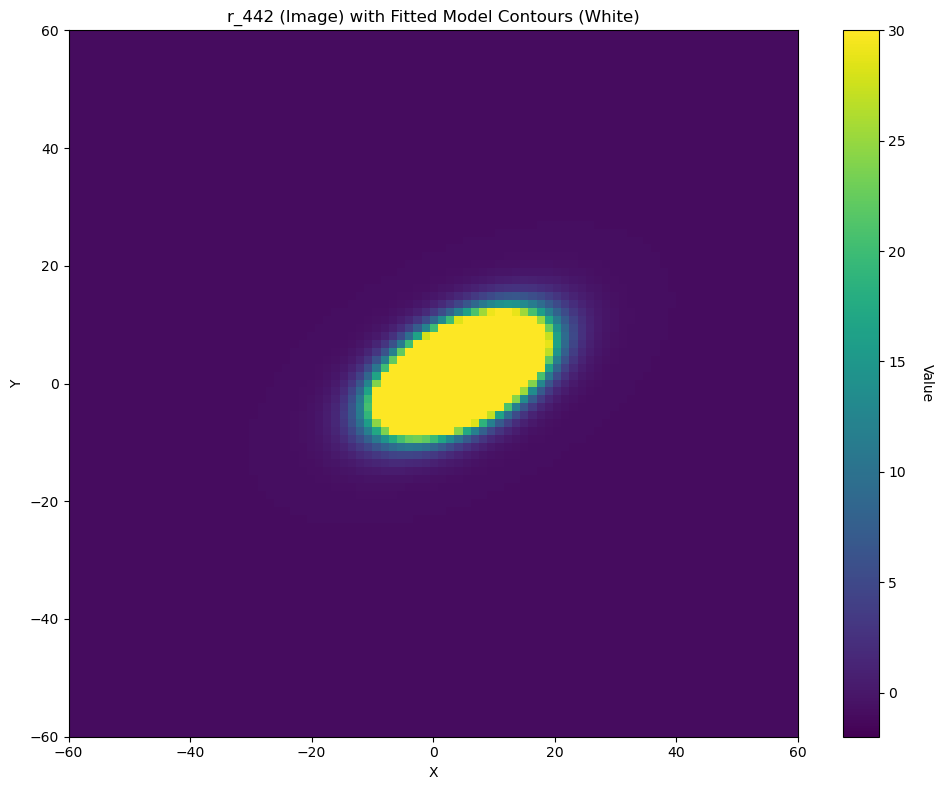

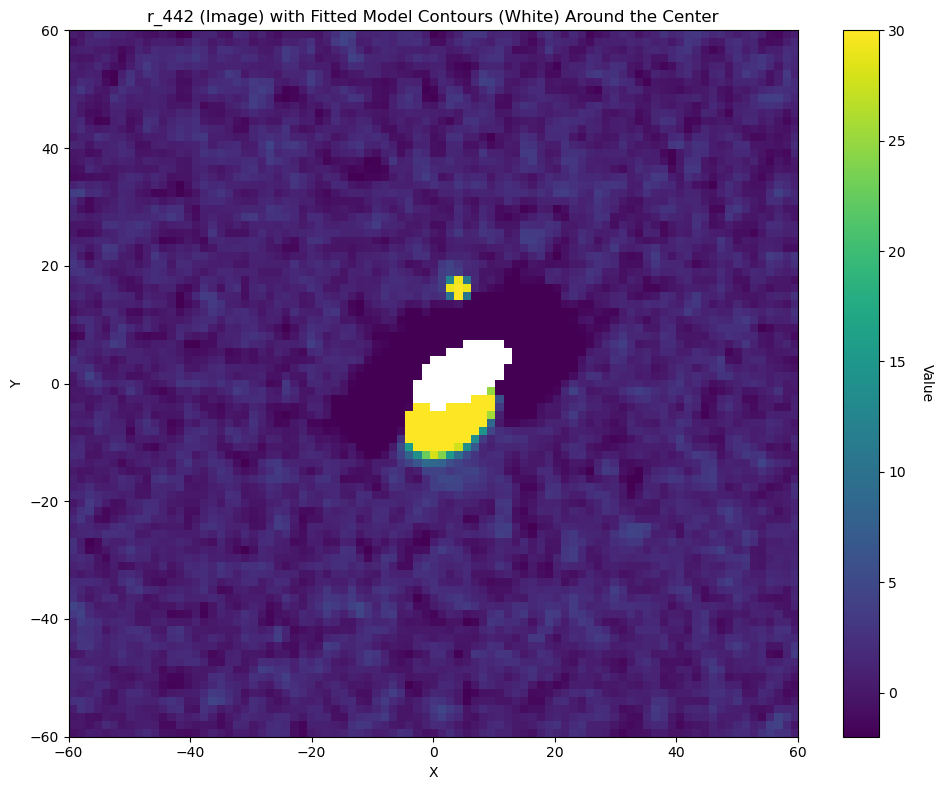

File name: mf_r_442_d=42.3_a=255.0_pix=8000.fits
Fitted Parameters:
A  = 6806.4178
h = 1.7515
q = 1.7178
x_offset = 3.3714
y_offset = -0.3103
theta = -9170286.8056
C  = -0.2050


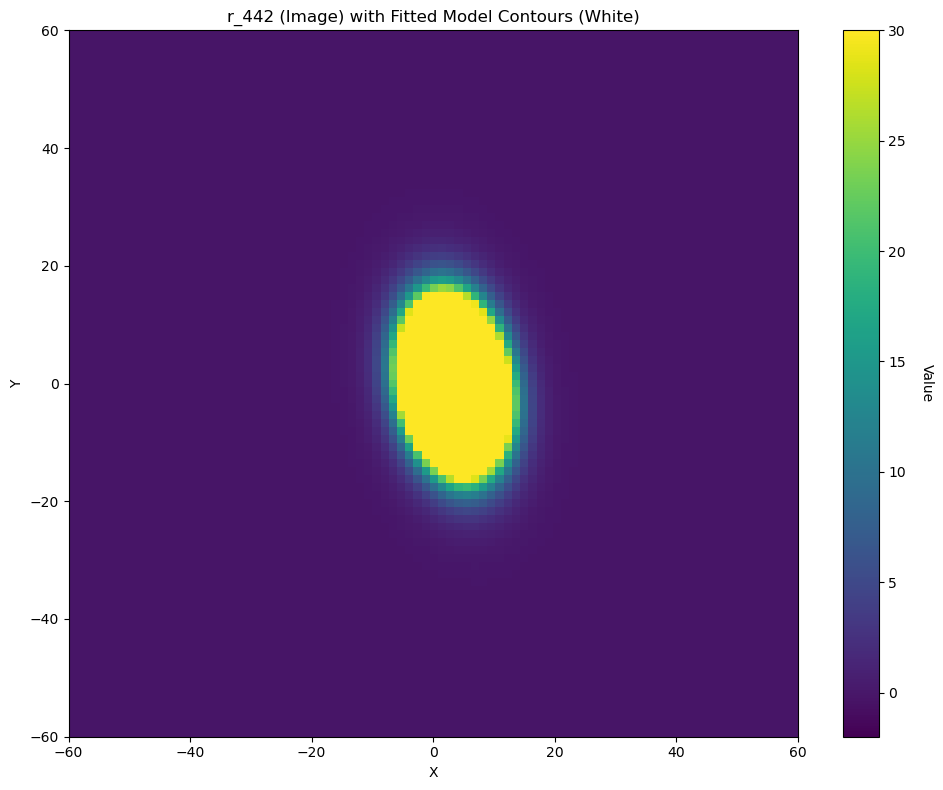

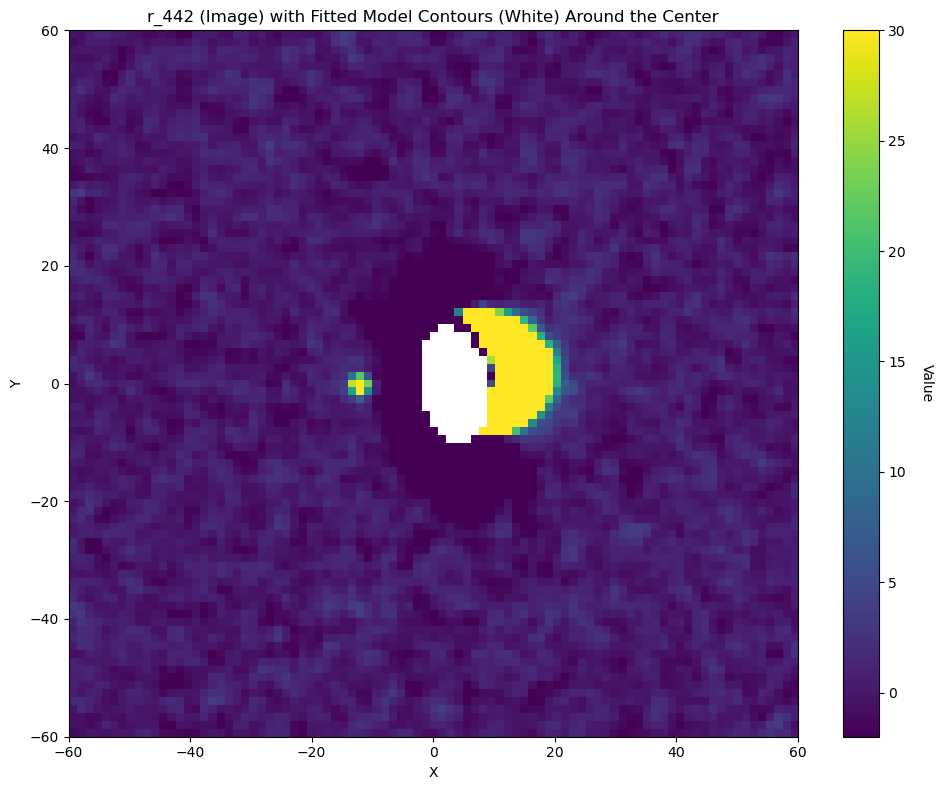

File name: mf_r_442_d=45.9_a=117.4_pix=8000.fits
Fitted Parameters:
A  = 11682.2279
h = 1.6161
q = 1.2481
x_offset = 4.9633
y_offset = -1.1816
theta = 2043588.1873
C  = -0.7145


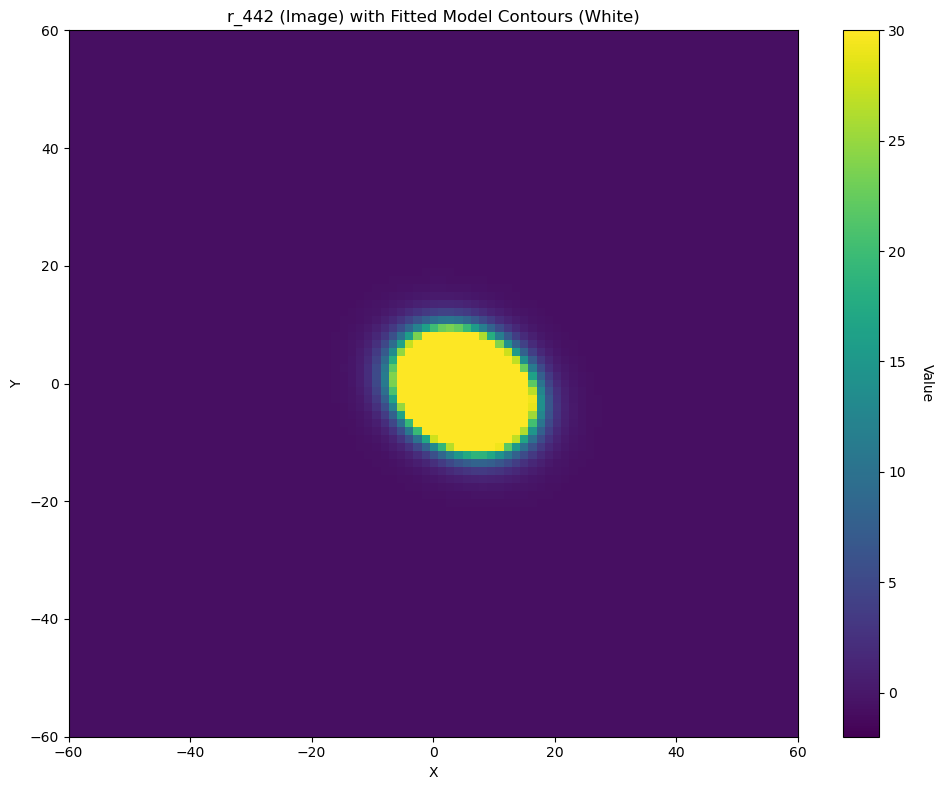

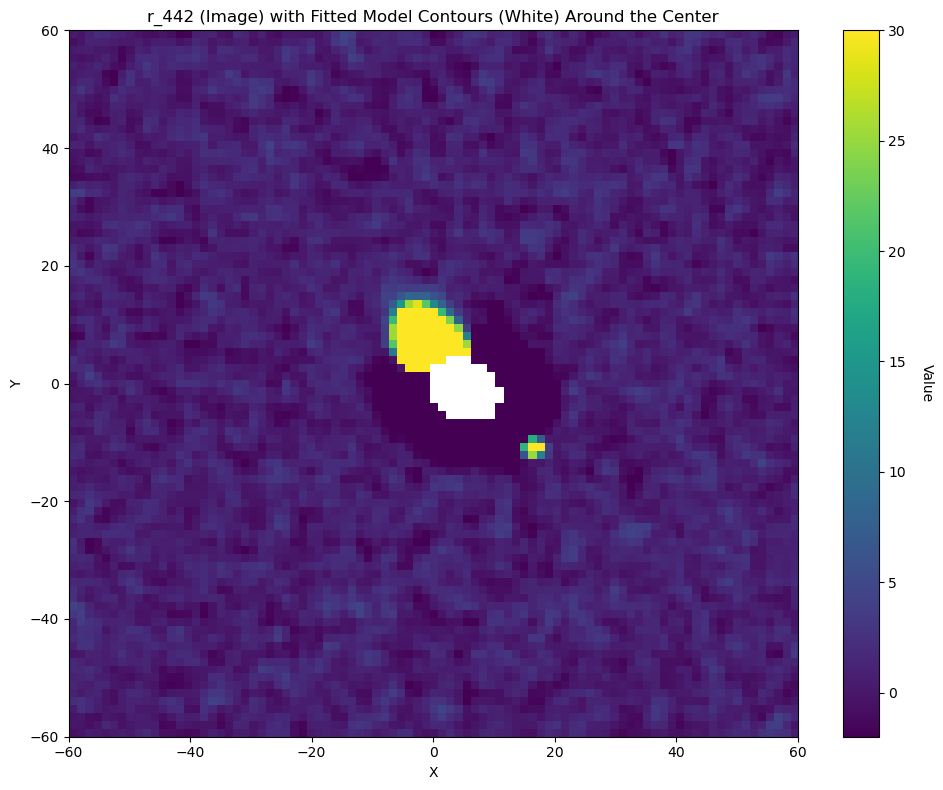

File name: mf_r_442_d=49.3_a=339.9_pix=8000.fits
Fitted Parameters:
A  = 8314.5889
h = 1.4501
q = 2.1842
x_offset = 3.3866
y_offset = 0.5819
theta = -7666363.1453
C  = -0.7678


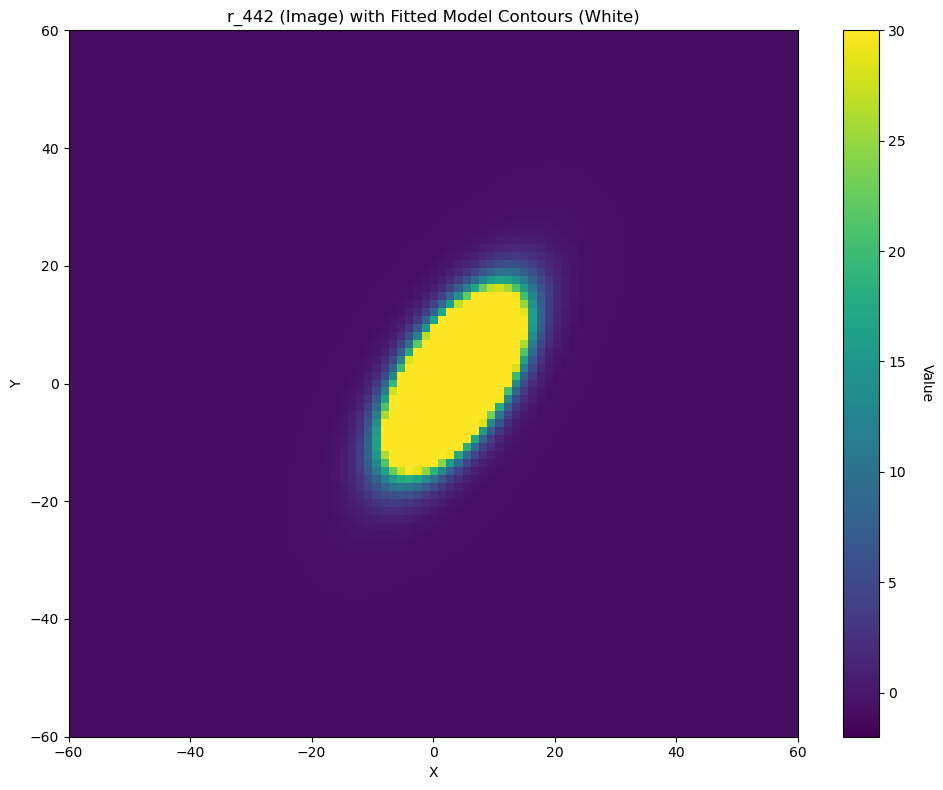

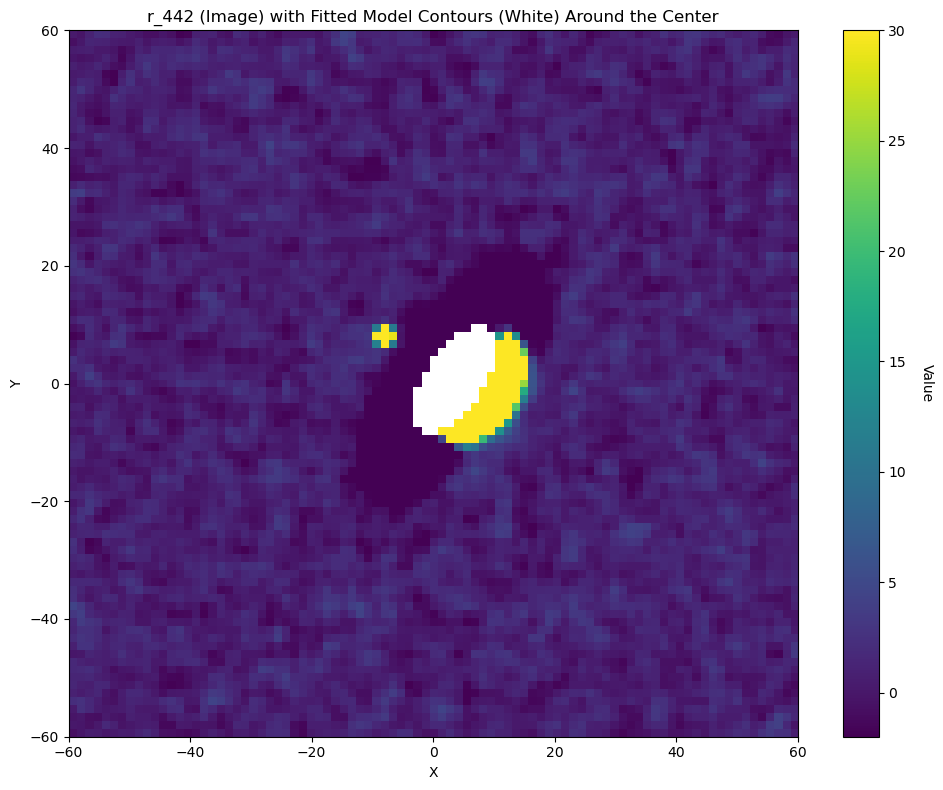

File name: mf_r_442_d=52.5_a=202.4_pix=8000.fits
Fitted Parameters:
A  = 7408.8185
h = 1.6038
q = 1.9812
x_offset = 3.6137
y_offset = -0.6771
theta = -7424440.5464
C  = -0.6577


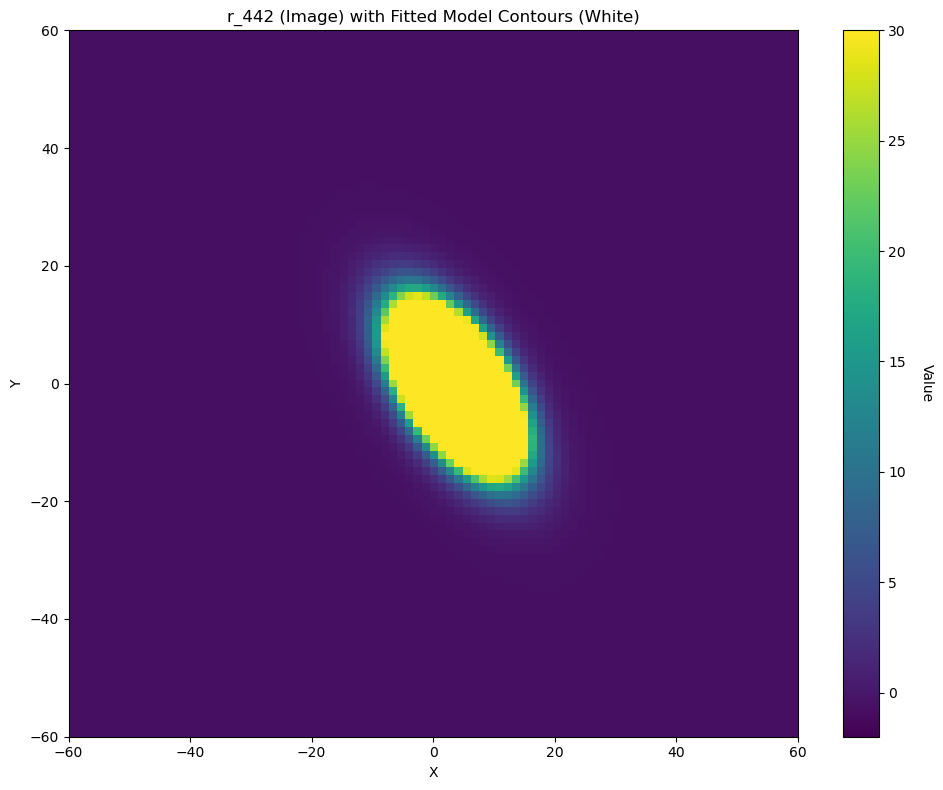

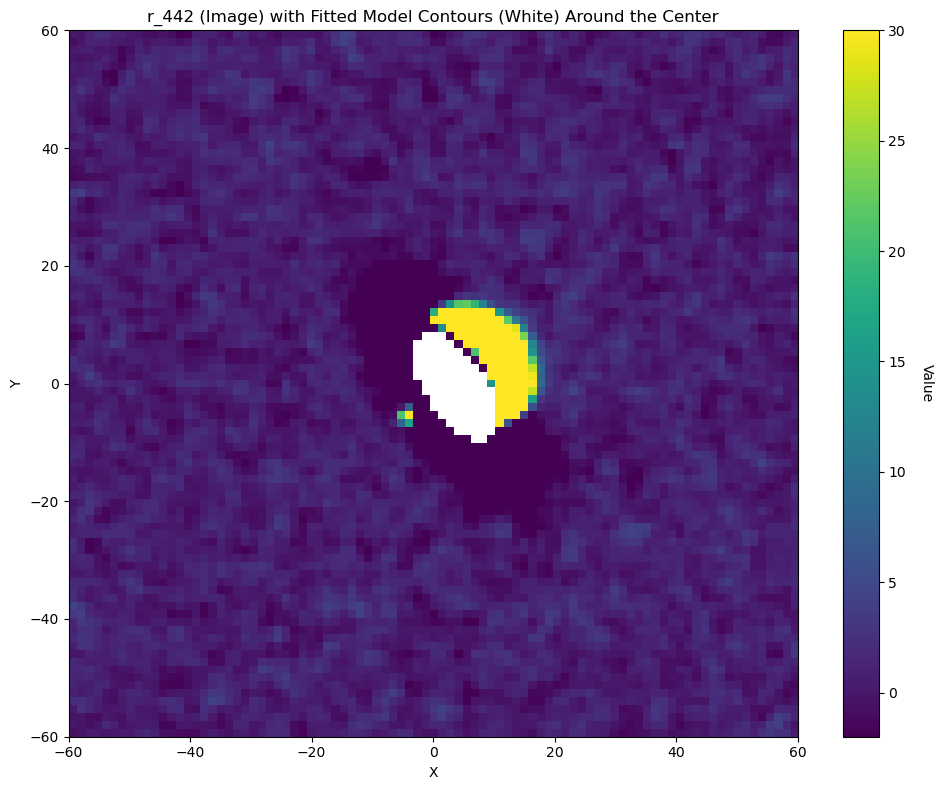

File name: mf_r_442_d=55.6_a=64.9_pix=8000.fits
Fitted Parameters:
A  = 15875.6128
h = 2.1086
q = 0.5355
x_offset = 4.8894
y_offset = 0.8334
theta = 5930372.1047
C  = -0.3126


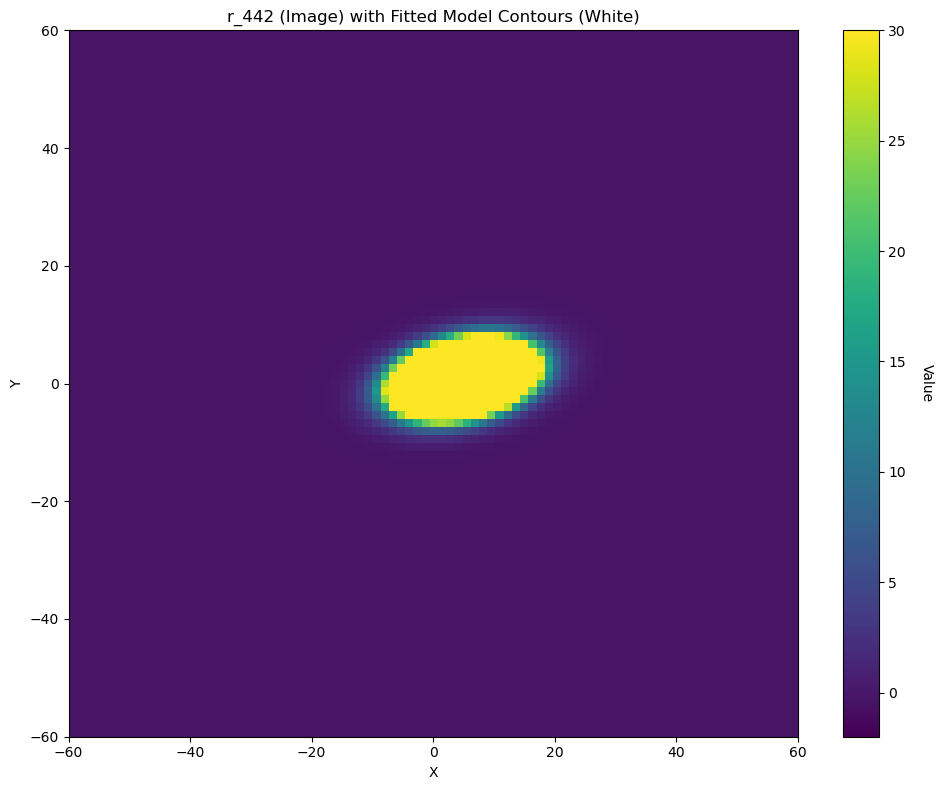

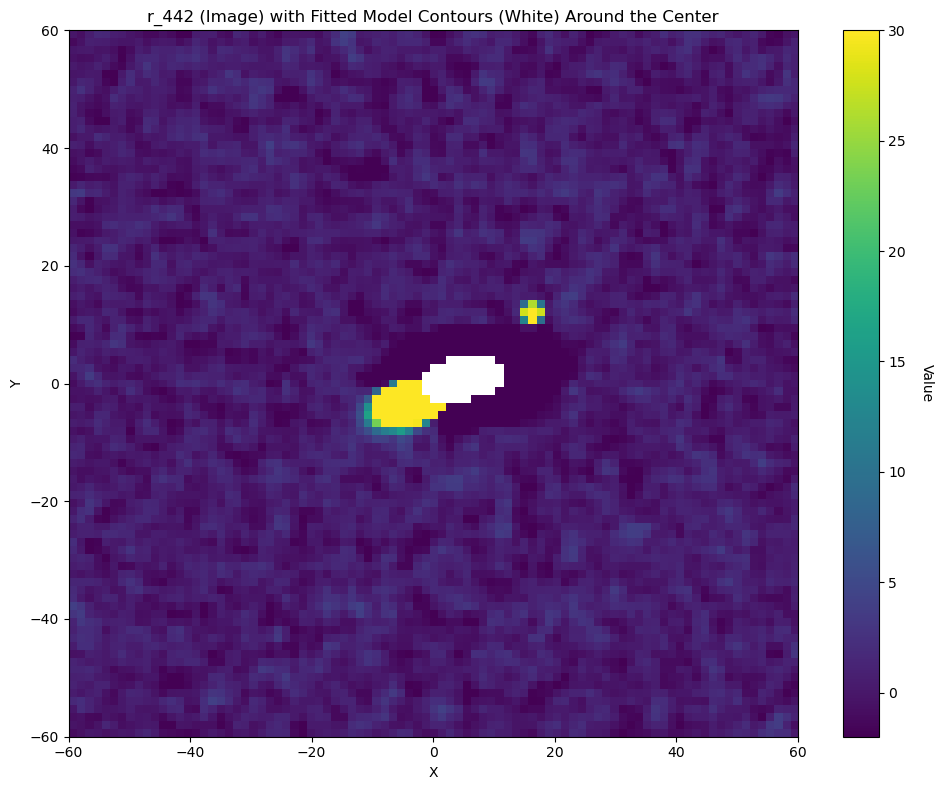

File name: mf_r_442_d=58.6_a=287.4_pix=8000.fits
Fitted Parameters:
A  = 7896.9947
h = 2.7213
q = 0.6287
x_offset = 3.1335
y_offset = -0.0730
theta = -15967551.7867
C  = -0.4331


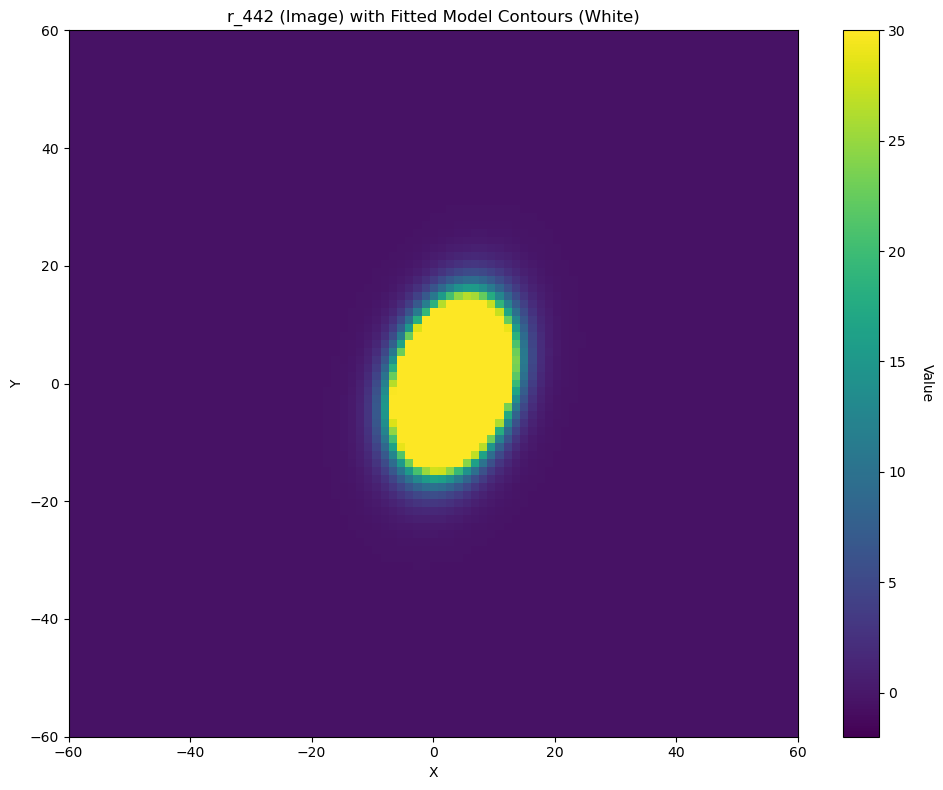

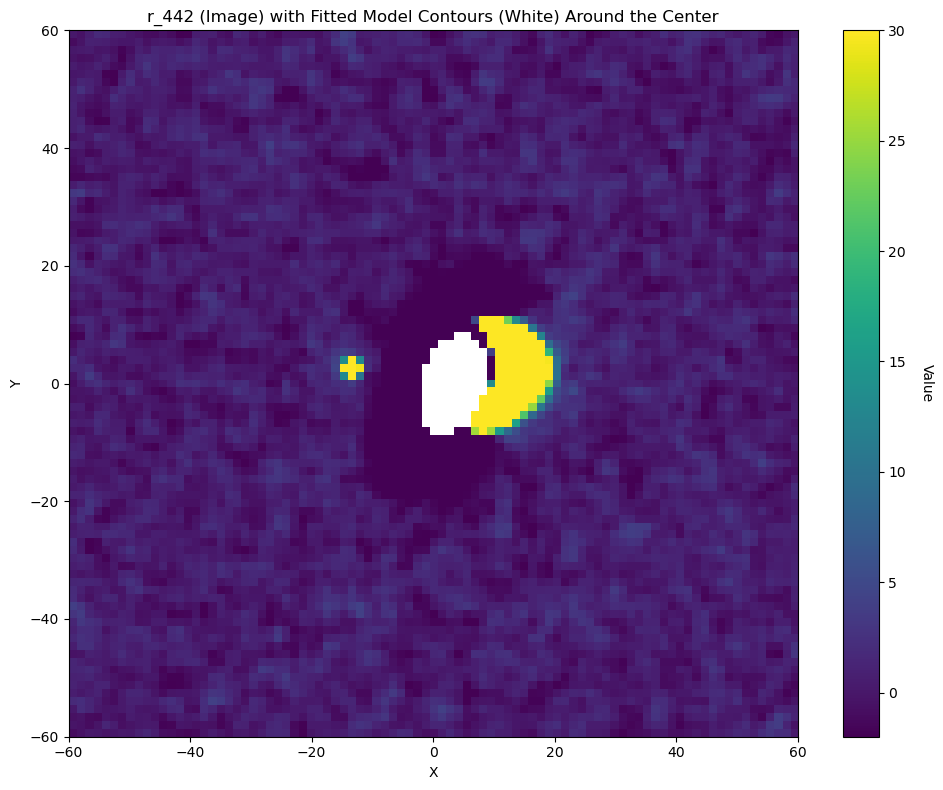

File name: mf_r_442_d=61.4_a=149.9_pix=8000.fits
Fitted Parameters:
A  = 10828.9909
h = 1.3569
q = 2.0006
x_offset = 3.7656
y_offset = -1.1433
theta = -12745001.1505
C  = -1.2548


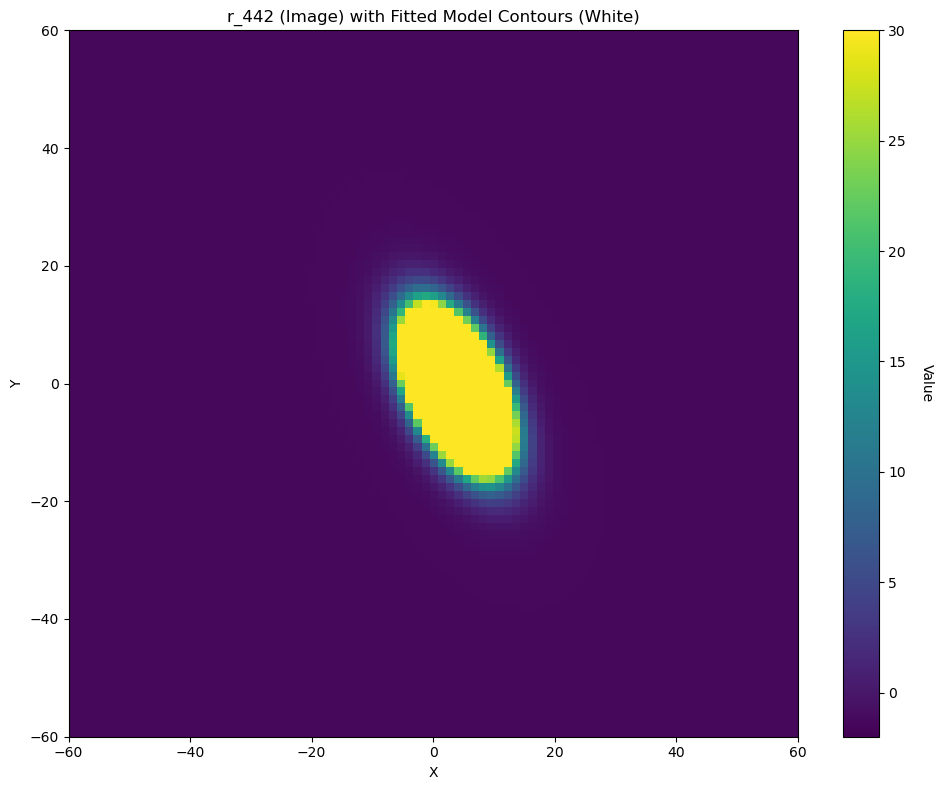

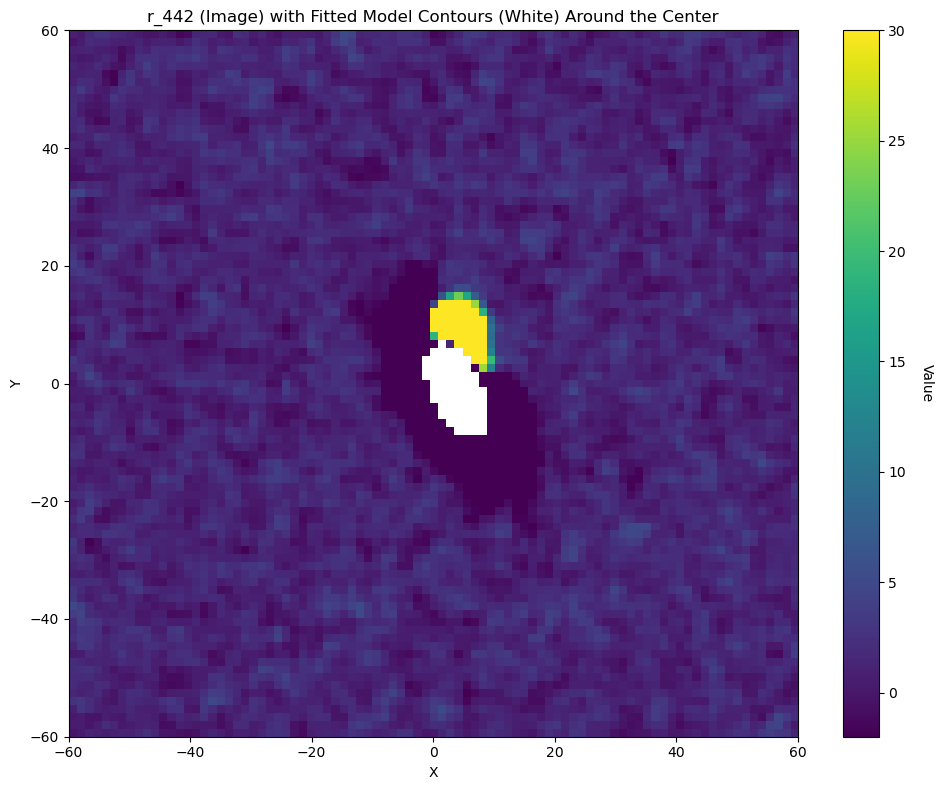

File name: mf_r_442_d=64.2_a=12.4_pix=8000.fits
Fitted Parameters:
A  = 10797.6629
h = 3.1800
q = 0.3802
x_offset = 3.5417
y_offset = 0.5071
theta = -10350186.4326
C  = -1.8614


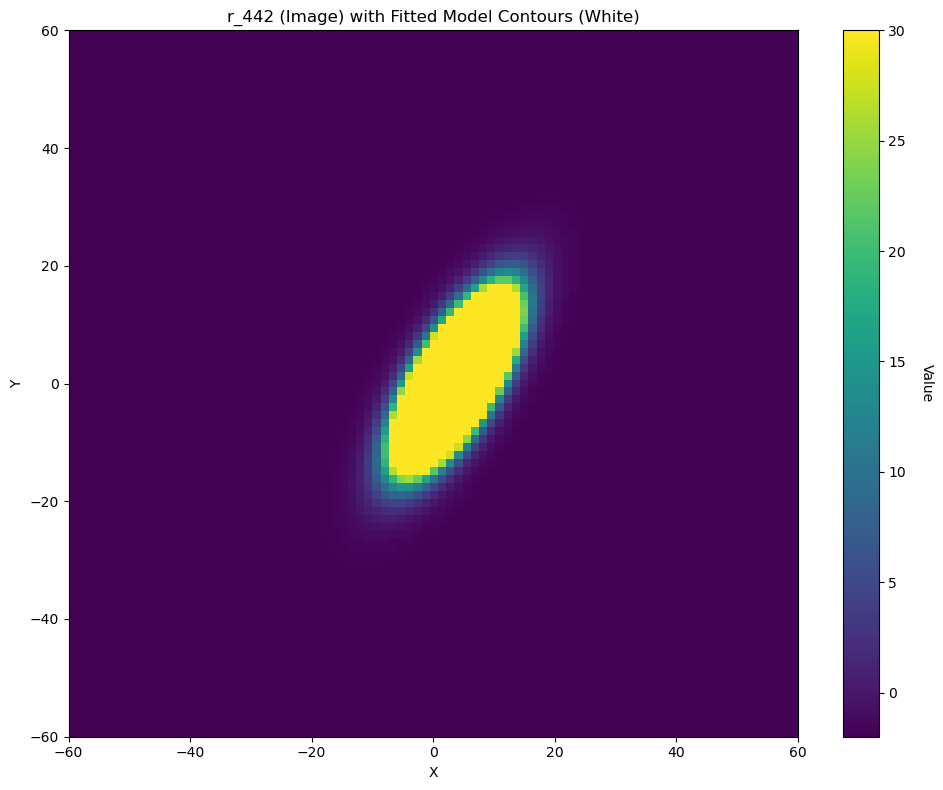

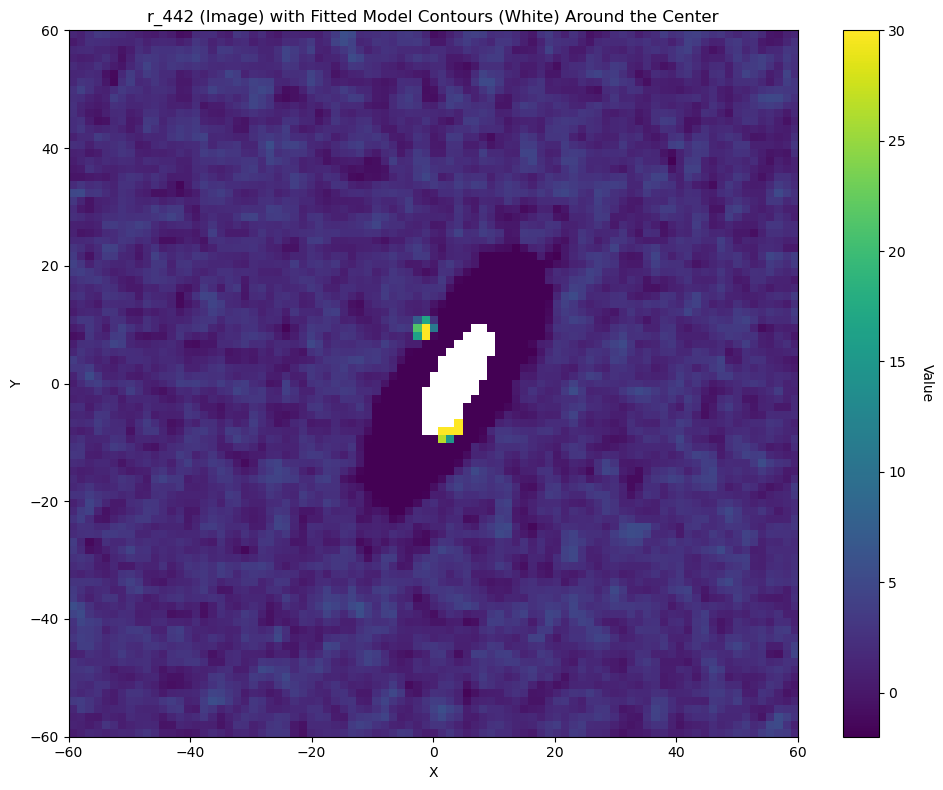

File name: mf_r_442_d=67.0_a=234.9_pix=8000.fits
Fitted Parameters:
A  = 8150.8229
h = 1.6197
q = 1.7411
x_offset = 3.1994
y_offset = -0.2355
theta = -12478138.4685
C  = -0.4406


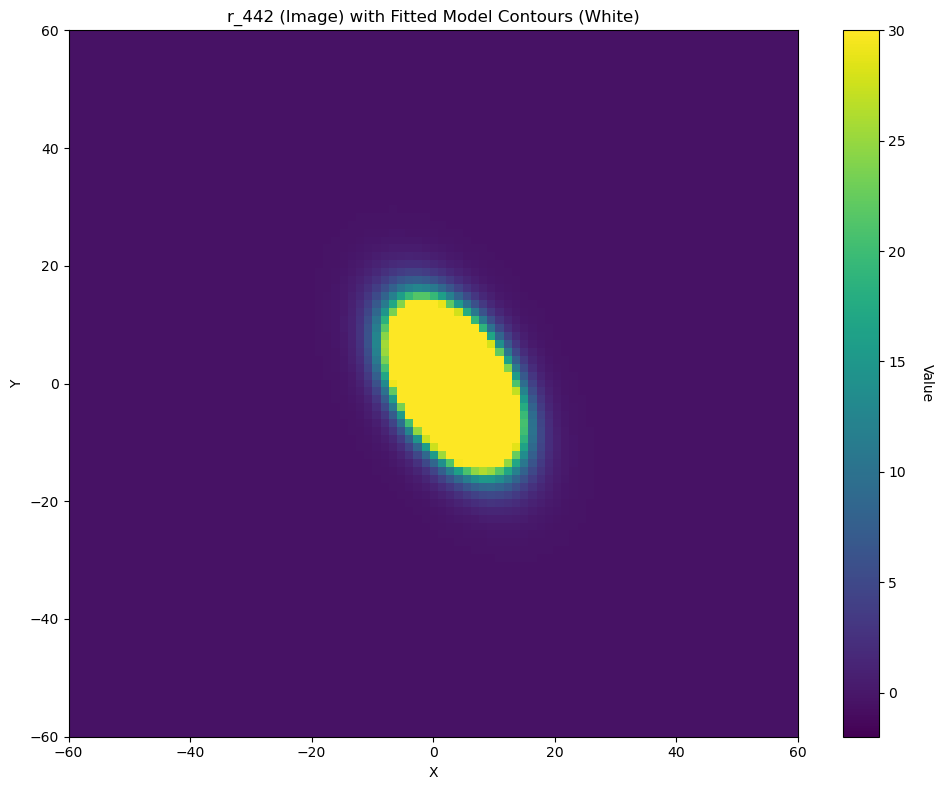

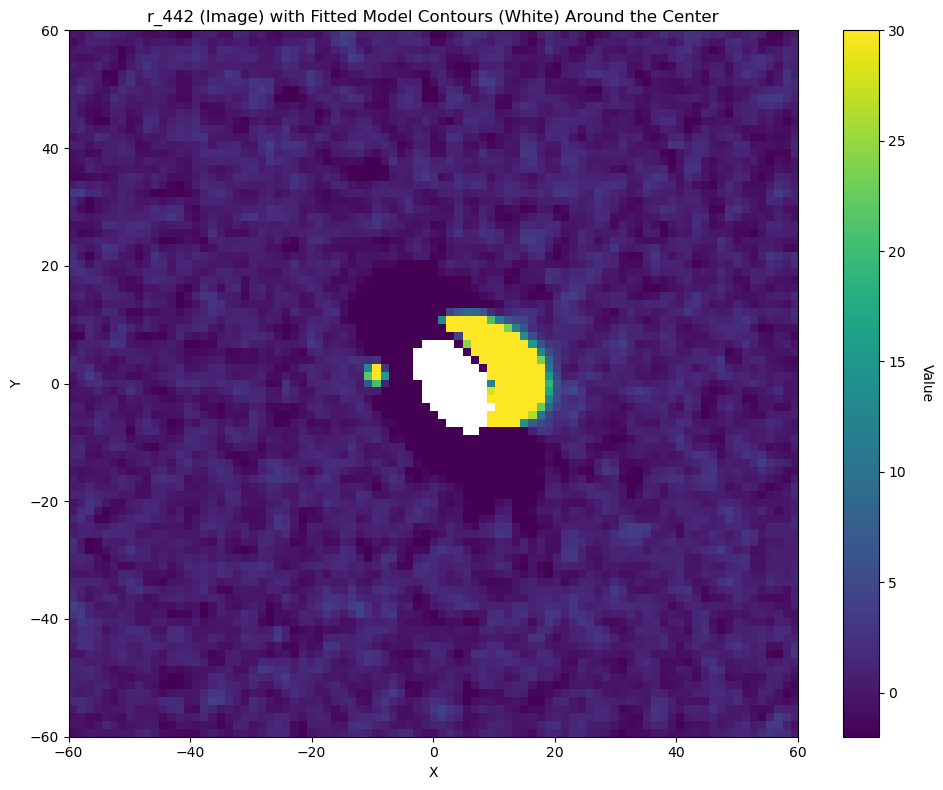

File name: mf_r_442_d=69.6_a=97.4_pix=8000.fits
Fitted Parameters:
A  = 19492.7514
h = 1.8107
q = 0.5796
x_offset = 4.7181
y_offset = -1.2489
theta = -14974238.9897
C  = -0.0108


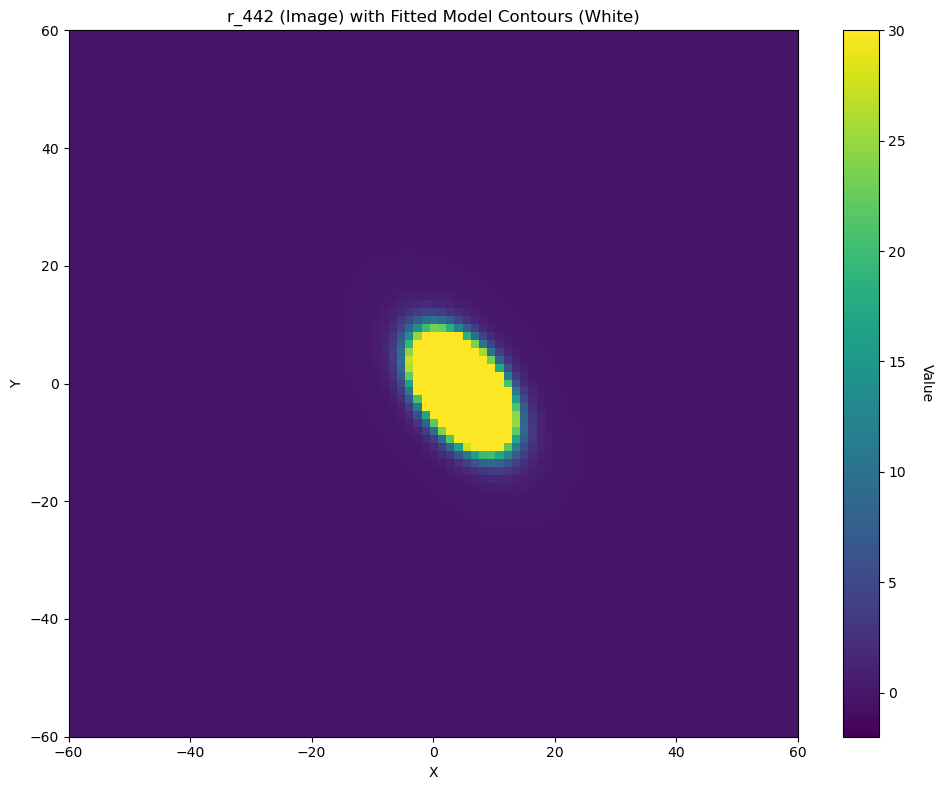

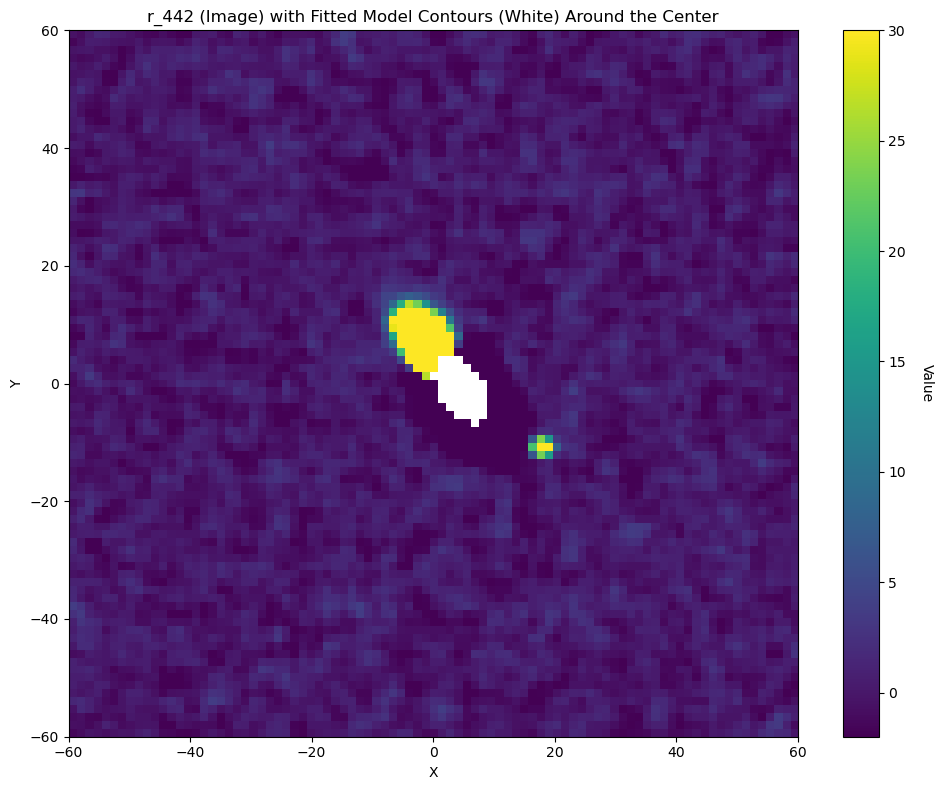

File name: mf_r_442_d=72.3_a=319.9_pix=8000.fits
Fitted Parameters:
A  = 9963.6938
h = 1.3431
q = 2.1725
x_offset = 3.0256
y_offset = -0.3051
theta = -12095295.6670
C  = -1.0226


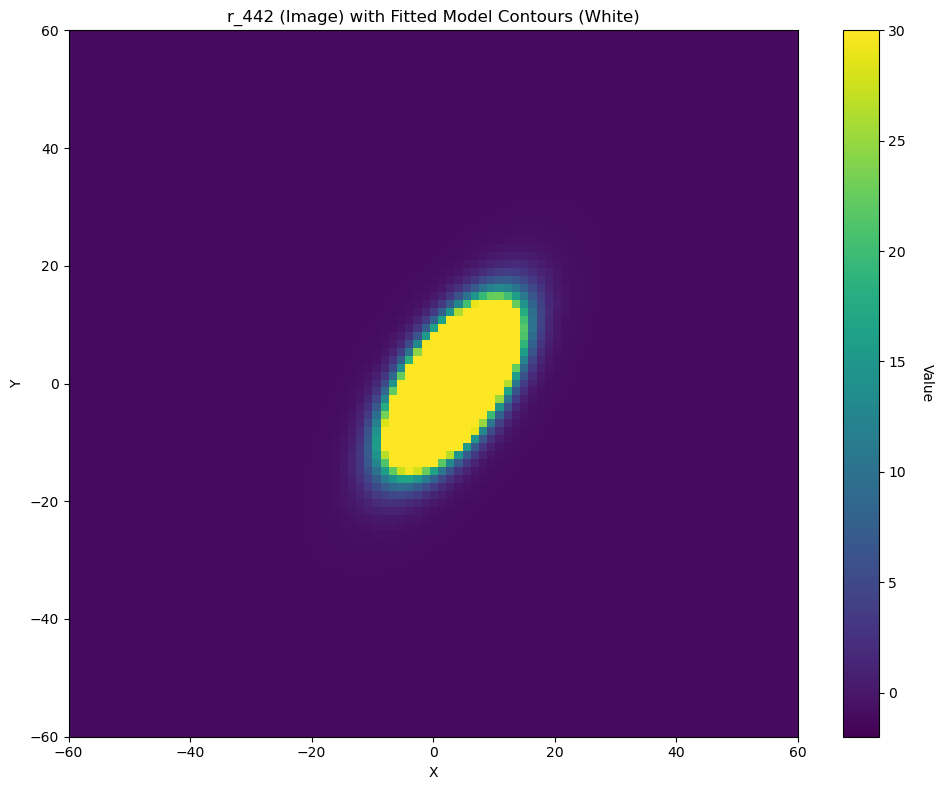

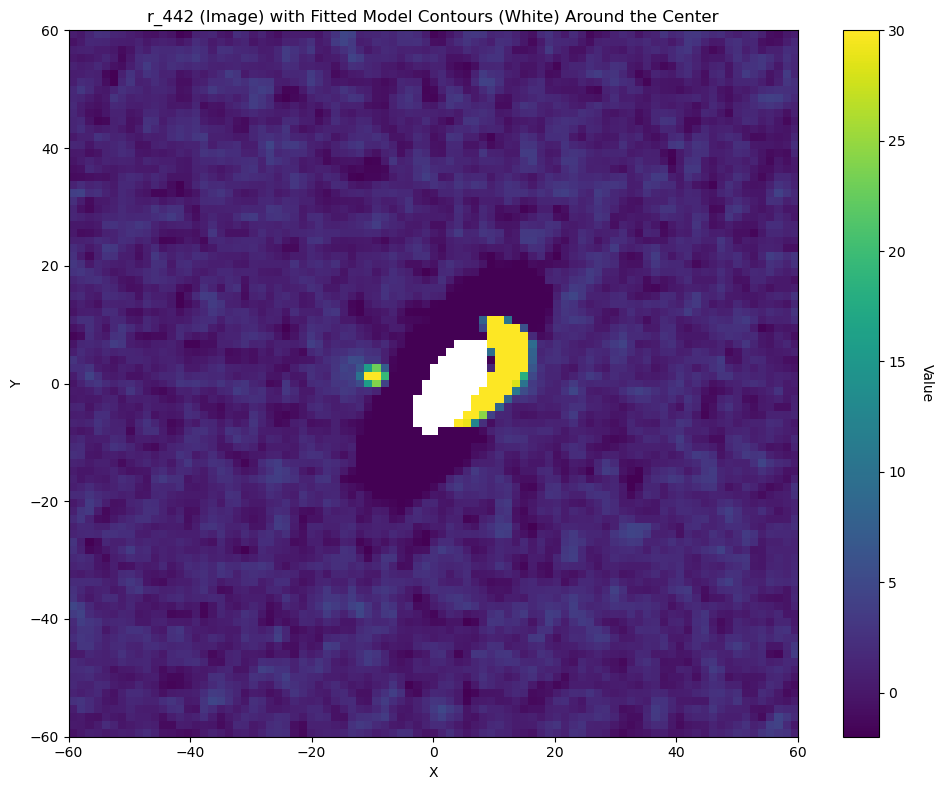

File name: mf_r_442_d=74.9_a=182.4_pix=8000.fits
Fitted Parameters:
A  = 9794.9099
h = 1.2818
q = 2.4836
x_offset = 3.5723
y_offset = -0.4891
theta = -2835833.6208
C  = -1.2934


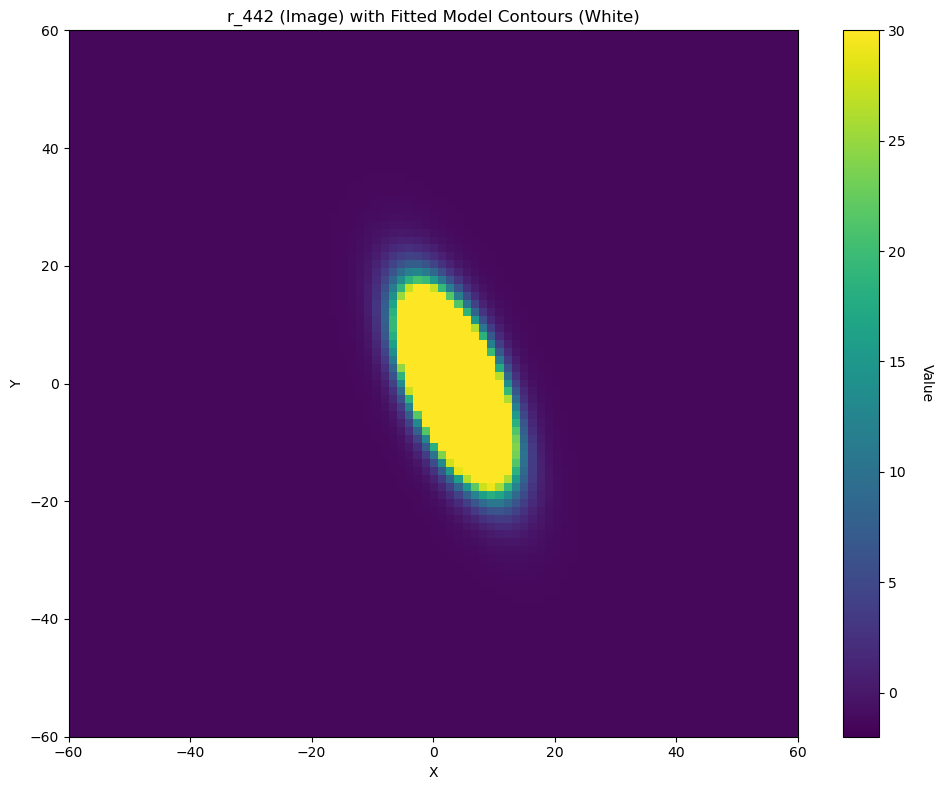

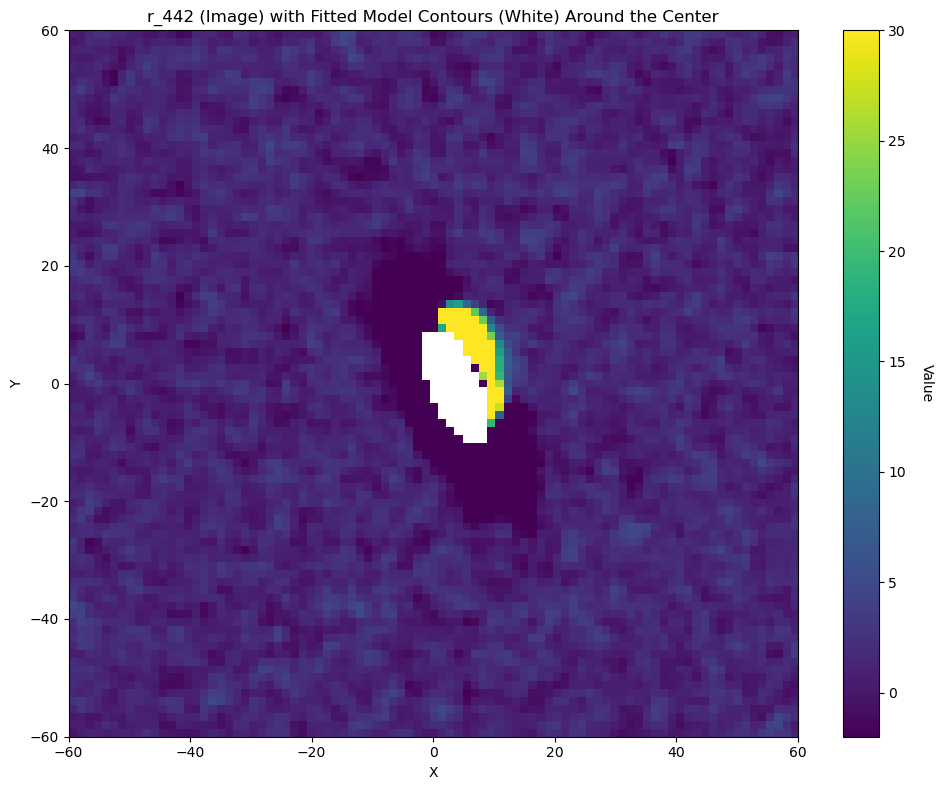

File name: mf_r_442_d=77.4_a=44.9_pix=8000.fits
Fitted Parameters:
A  = 12450.6927
h = 2.6625
q = 0.4504
x_offset = 4.6784
y_offset = 0.5753
theta = 1928288.1481
C  = -1.2265


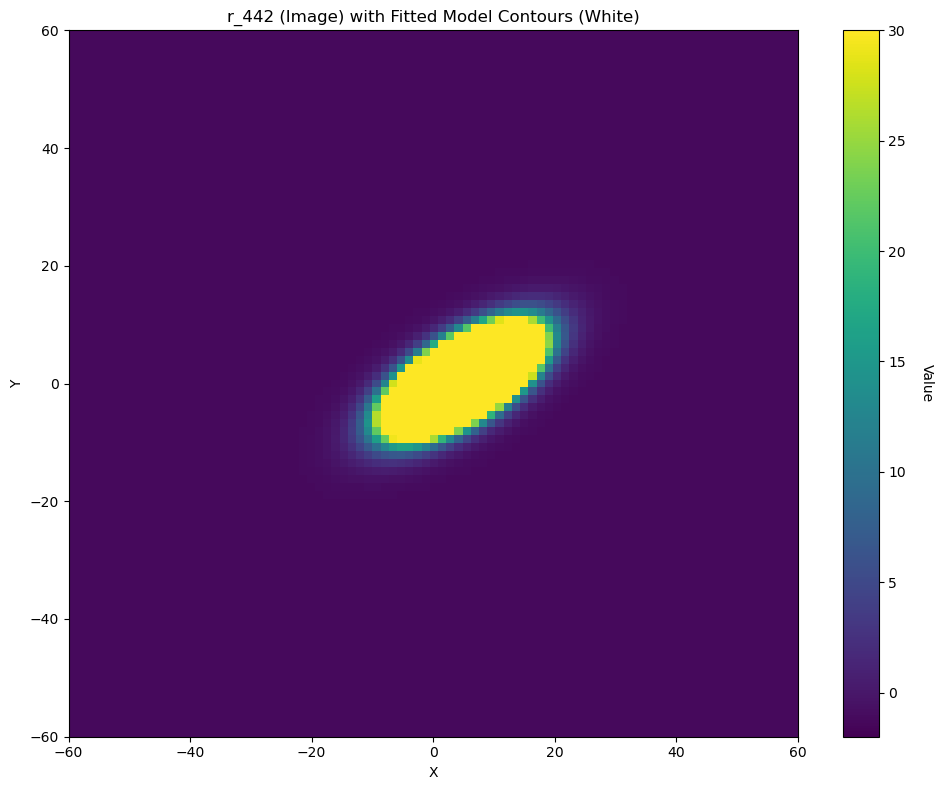

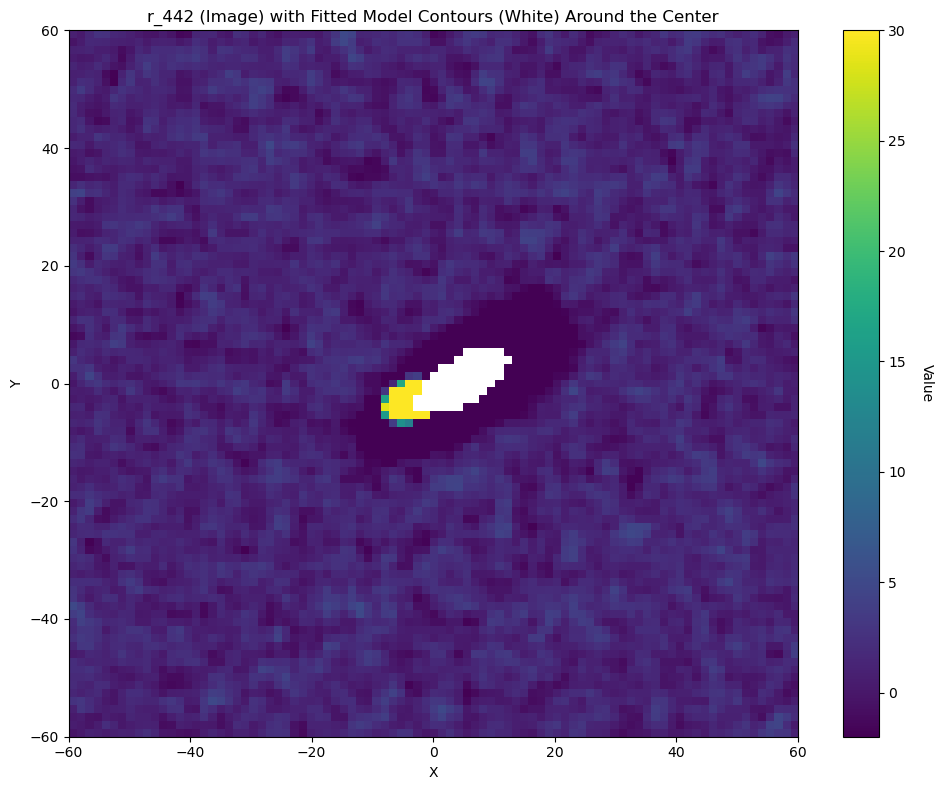

File name: mf_r_442_d=80.0_a=267.4_pix=8000.fits
Fitted Parameters:
A  = 10646.8871
h = 1.9290
q = 0.9178
x_offset = 2.3085
y_offset = -0.2214
theta = -14676397.3509
C  = -0.1270


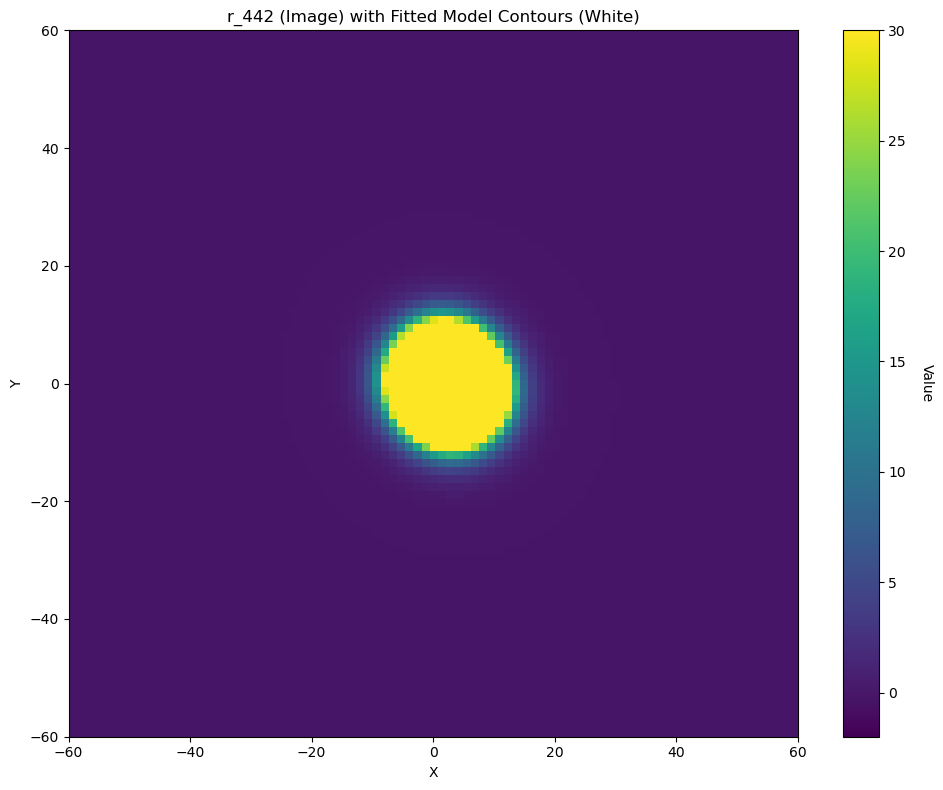

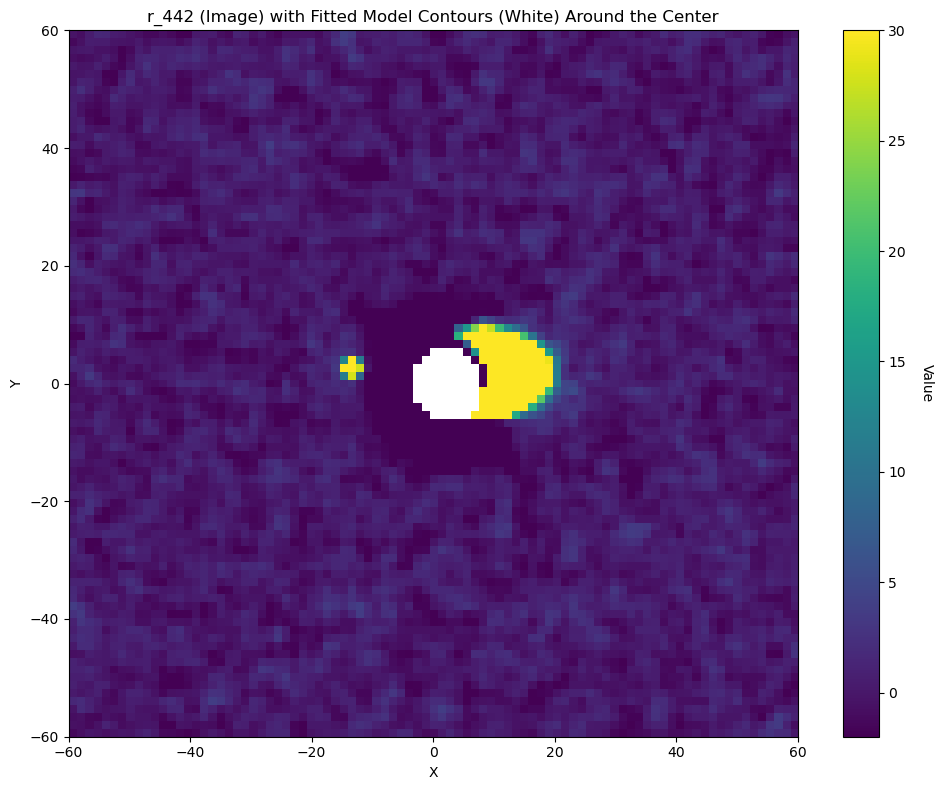

File name: mf_r_442_d=82.5_a=129.8_pix=8000.fits
Fitted Parameters:
A  = 13887.8113
h = 1.1680
q = 2.0864
x_offset = 4.4023
y_offset = -1.4303
theta = -20586281.5446
C  = -1.1979


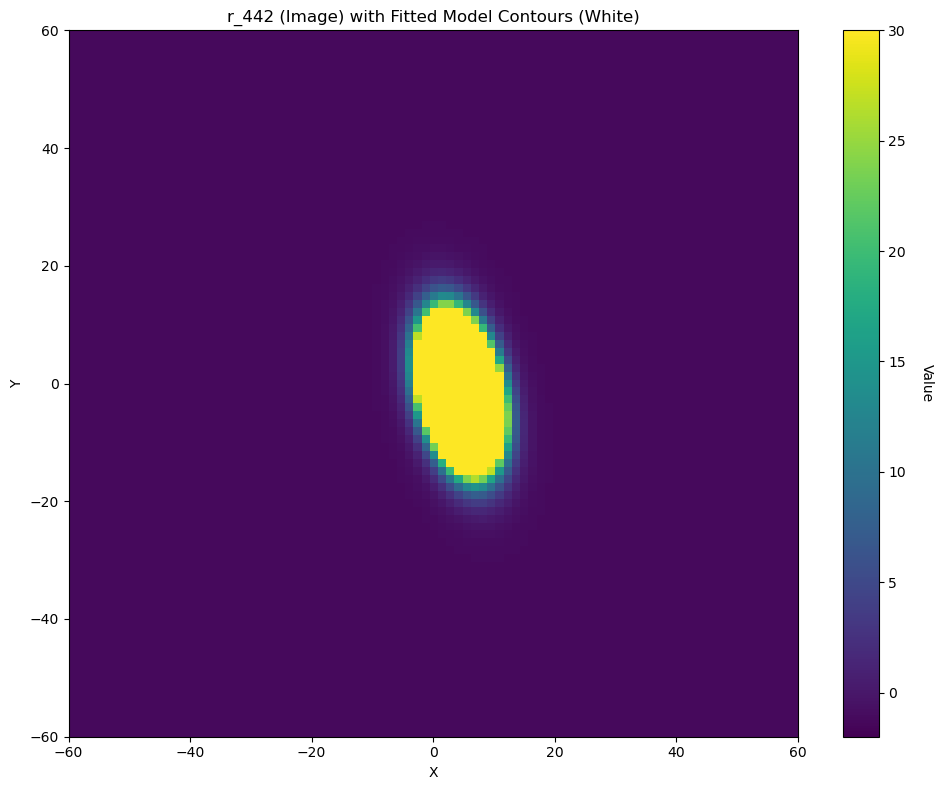

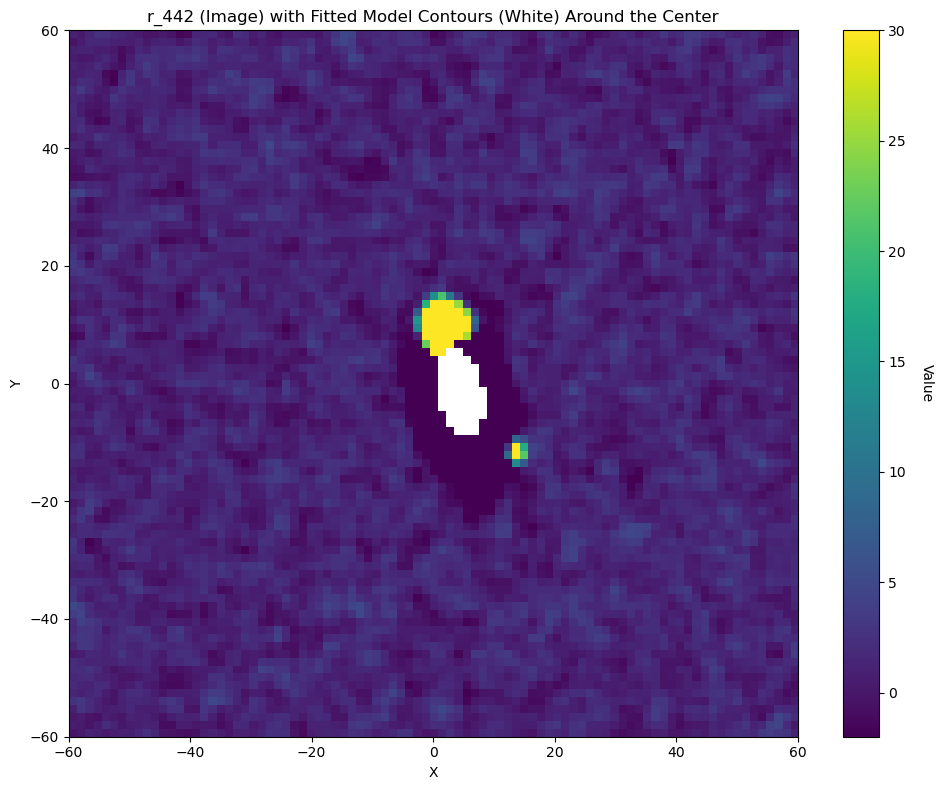

File name: mf_r_442_d=85.0_a=352.3_pix=8000.fits
Fitted Parameters:
A  = 11293.6994
h = 3.3108
q = 0.3385
x_offset = 3.4430
y_offset = -0.2215
theta = -13899947.4435
C  = -2.0764


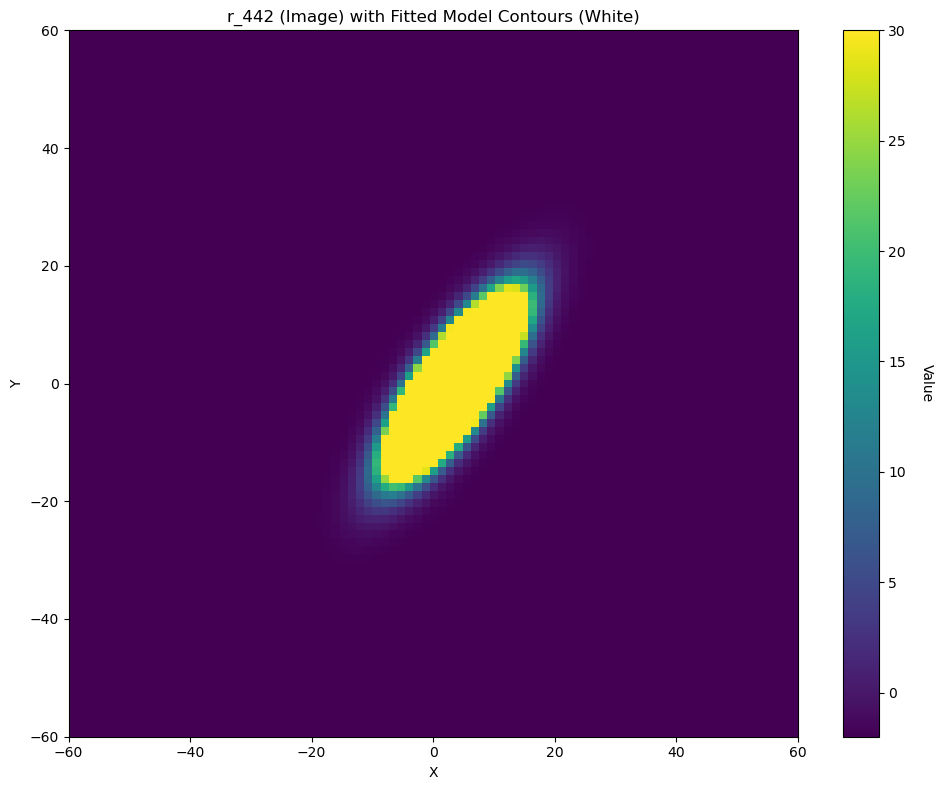

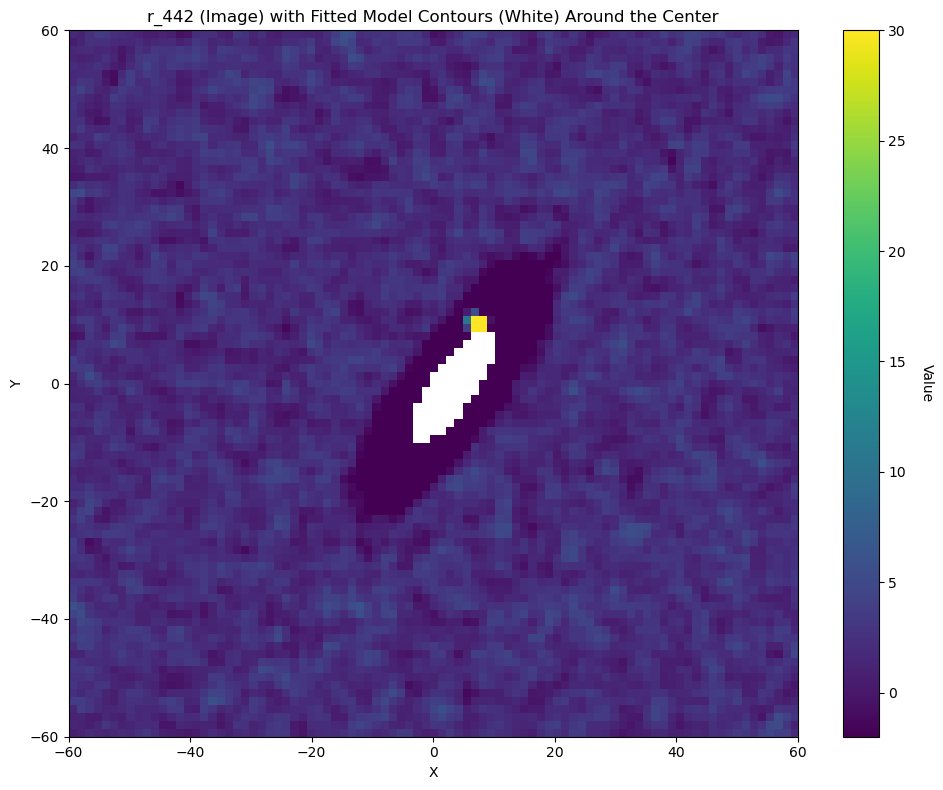

File name: mf_r_442_d=87.5_a=214.8_pix=8000.fits
Fitted Parameters:
A  = 10241.3561
h = 1.2832
q = 2.3426
x_offset = 3.0608
y_offset = 0.2542
theta = -11101014.9440
C  = -1.0572


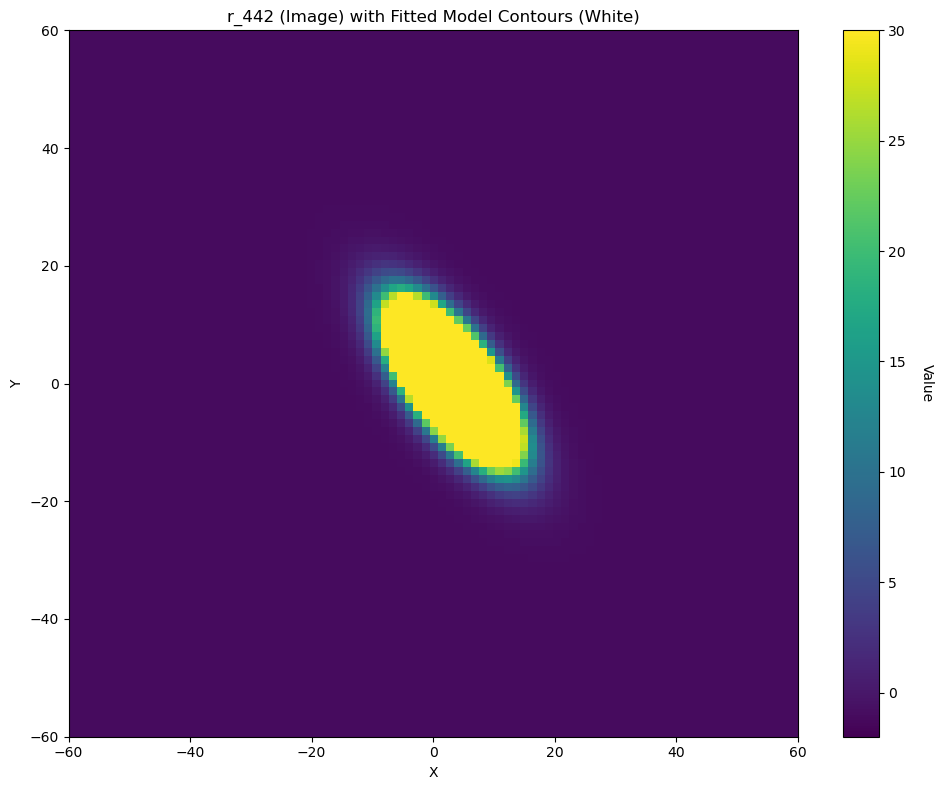

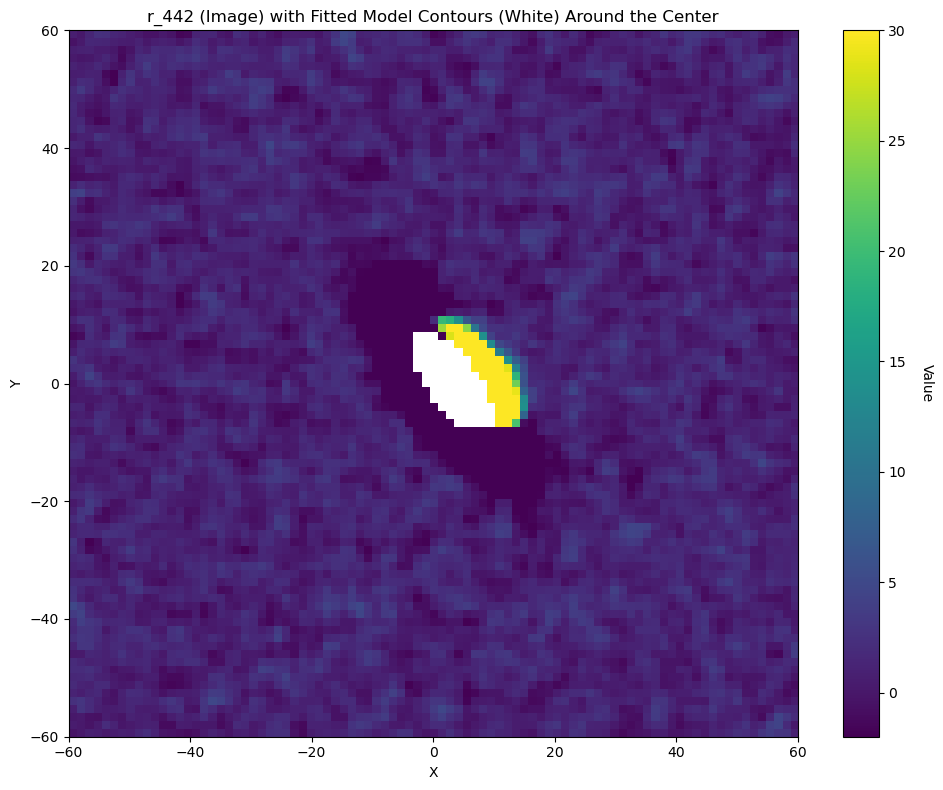

File name: mf_r_442_d=90.0_a=77.3_pix=8000.fits
Fitted Parameters:
A  = 13427.8486
h = 1.9400
q = 0.7109
x_offset = 5.5485
y_offset = -0.6800
theta = -11190843.0861
C  = 0.2674


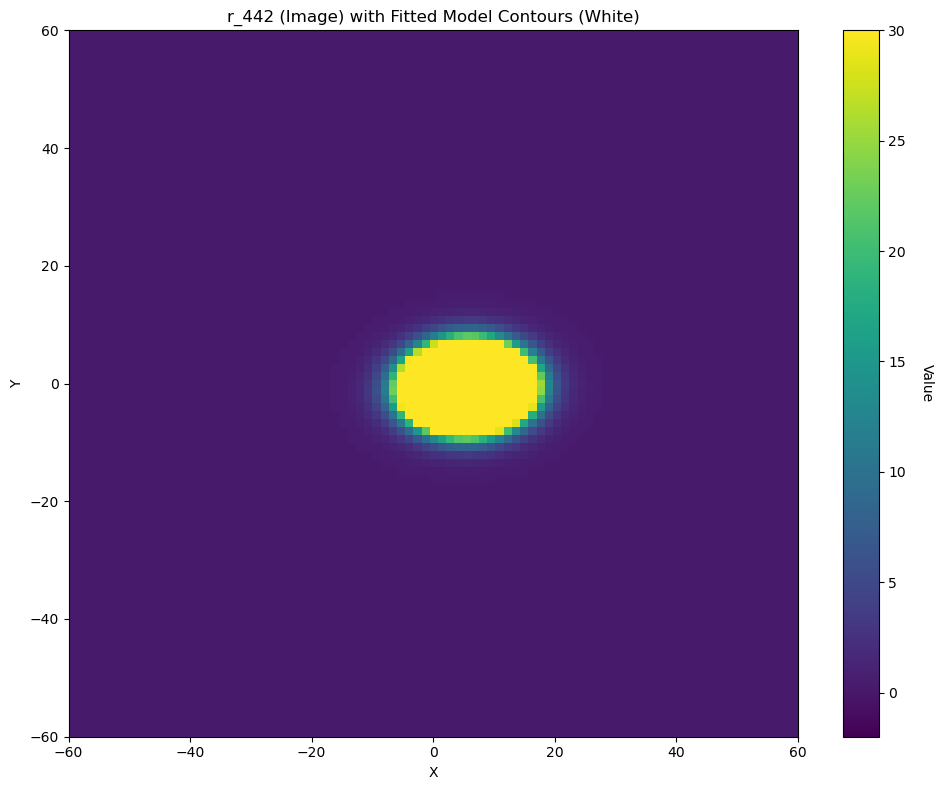

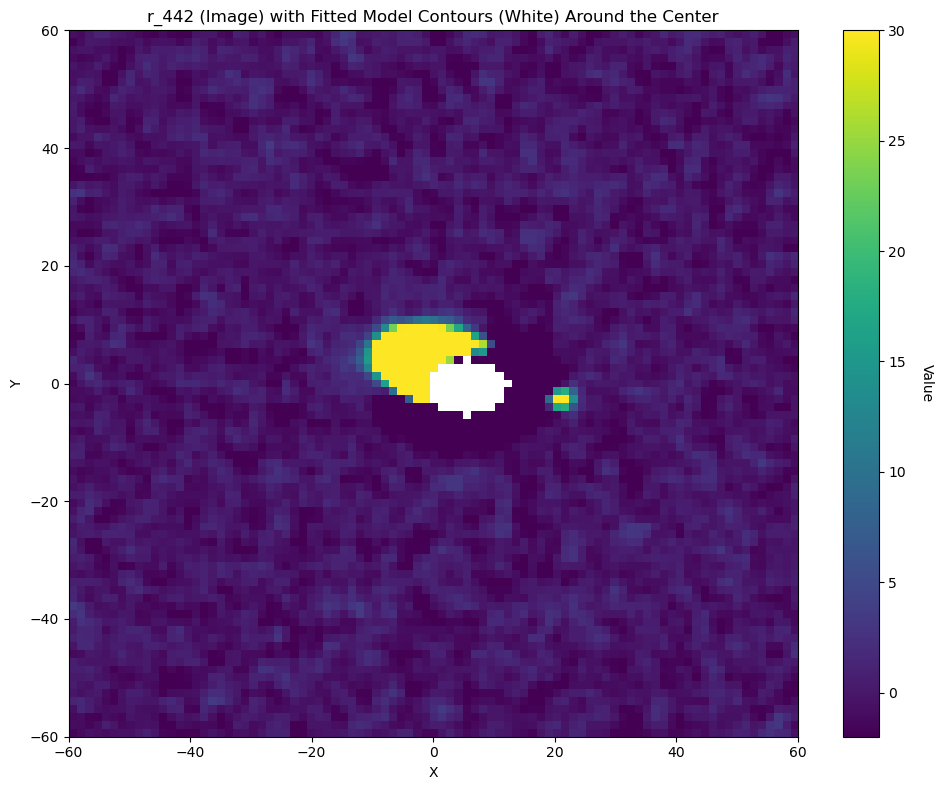

In [8]:
if os.path.exists(centers_path):
    os.remove(centers_path)

for file in sorted(mf_catalogs_path.iterdir()):
    if file.is_file():

        print(f'File name: {file.name}')

        numbers = [float(num) for num in re.findall(r'\d+(?:\.\d+)*', f'{file.name}')]
        angles = numbers[1:-1]
        d = angles[0]
        a = angles[1]
        
        hdul = fits.open(f'{mf_catalogs_path}/{file.name}')
        data=hdul[0].data

        # Generate synthetic mock data with noise
        x_line = np.linspace(-60, 60, 89)
        y_line = np.linspace(-60, 60, 89)
        X, Y = np.meshgrid(x_line, y_line)
        
        # Flatten the arrays to 1-D for curve_fit
        x_flat = X.ravel()
        y_flat = Y.ravel()
        z_flat = data.ravel()
        
        # Combine independent variables into an (2, N) shaped array
        independent_vars = np.vstack((x_flat, y_flat))
        
        # Perform the optimization
        fitted_params, covariance = curve_fit(
            f=exponential_2d, 
            xdata=independent_vars, 
            ydata=z_flat, 
            p0=initial_guess
        )

        Z_fitted = exponential_2d((X, Y), *fitted_params)

        z_fit_max = np.max(Z_fitted)
        mask_thresh = .05 * z_fit_max # Change thresh to what you want
        mask = Z_fitted < mask_thresh
        residual = data - Z_fitted
        masked_residual = residual.copy()
        masked_residual[~mask] = np.nan

        # Extract and view results
        A_fit, h_fit, q_fit, x_offset_fit, y_offset_fit, theta_fit, C_fit = fitted_params
        print("Fitted Parameters:")
        print(f"A  = {A_fit:.4f}")
        print(f"h = {h_fit:.4f}")
        print(f"q = {q_fit:.4f}")
        print(f"x_offset = {x_offset_fit:.4f}")
        print(f"y_offset = {y_offset_fit:.4f}")
        print(f"theta = {theta_fit:.4f}")
        print(f"C  = {C_fit:.4f}")

        with open(f'{centers_path}', 'a') as file:
            file.write('center of ' f'{galaxy_name}' ' at d=' f'{d}' ' and a=' f'{a}' ':' f'{x_offset_fit:.4f}' ',' f'{y_offset_fit:.4f}' '\n')

        zero_angle_check = not (any(x == 0 for x in angles))
        
        twod_exp_fit(Z_fitted, d, a, inv_y = False)
        twod_exp_fit_res(d, a, inv_y = False)